# Choice-based optimization

In [3]:
from datetime import datetime
from enum import Enum
from io import StringIO
import os
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
from pprint import pprint
import pyomo.environ as pyo

from IPython.display import display, Latex

from phdtools import PROJECT_ROOT

from phdtools import DATA_DIR, RESULTS_DIR, TMP_DIR
from phdtools.rdm import (
    DataID,
    DataType,
    Chapter,
    request_free_id,
    auto_create_path,
    write_metadata,
)

NUM_AGENTS = 16

TODAY = datetime.today().strftime("%y%m%d")

TIME_LIMIT_SECONDS = os.getenv("TIME_LIMIT_SECONDS", 30)
FILE_DATE = os.getenv("FILE_DATE", "260419")
FILE_DATE_DEMANDS = os.getenv("FILE_DATE_DEMANDS", "260419")
FILE_DATE_AGENTS = os.getenv("FILE_DATE_AGENTS", "260419")
FILE_DATE_SAMPLE = os.getenv("FILE_DATE_SAMPLE", "260419")
FILE_DATE_REGRESSION = os.getenv("FILE_DATE_REGRESSION", "260419")
FILE_DATE_COST_COEFS = os.getenv("FILE_DATE_COST_COEFS", "260419")
FILE_DATE_COST_MINIMIZATION = os.getenv("FILE_DATE_COST_MINIMIZATION", "260419")

overwrite = False
if overwrite:
    FILE_DATE = TODAY

## Table of contents

- [Model parameters](#Model-parameters)
  - [Bounds on price](#Bounds-on-price)
  - [Data preparation](#Data-preparation)
- [Profit maximization](#Profit-maximization)
    - [PM: Generate case](#PM:-Generate-case)
    - [PM: Problem statistics](#PM:-Problem-statistics)
    - [PM: Solve case](#PM:-Solve-case)
    - [PM: Verification](#PM:-Verification)
    - [PM: Solution summary](#PM:-Solution-summary)
- [Demand maximization with constant markup](#Demand-maximization-with-constant-markup)
  - [DM-1: Example](#DM-1:-Example)
    - [DM-1: Generate case](#DM-1:-Generate-case)
    - [DM-1: Problem statistics](#DM-1:-Problem-statistics)
    - [DM-1: Solve case](#DM-1:-Solve-case)
    - [DM-1: Verification](#DM-1:-Verification)
  - [DM-1: Parameter sweep](#DM-1:-Parameter-sweep)
    - [DM-1: Solution summary](#DM-1:-Solution-summary)
    - [DM-1: Solution statistics](#DM-1:-Solution-statistics)
- [Demand maximization with constant contribution](#Demand-maximization-with-constant-contribution)
  - [DM-2: Example](#DM-2:-Example)
    - [DM-2: Generate case](#DM-2:-Generate-case)
    - [DM-2: Problem statistics](#DM-2:-Problem-statistics)
    - [DM-2: Solve case](#DM-2:-Solve-case)
    - [DM-2: Verification](#DM-2:-Verification)
  - [DM-2: Parameter sweep](#DM-2:-Parameter-sweep)
    - [DM-2: Solution summary](#DM-2:-Solution-summary)
    - [DM-2: Solution statistics](#DM-2:-Solution-statistics)
- [Comparison of optimization results](#Comparison-of-optimization-results)
- [Comparison of computational performance](#Comparison-of-computational-performance)
  - [Problem statistics](#Problem-statistics)

### Model parameters
[back](#Table-of-contents)

In [4]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)}

260419_socio_demographic_attributes_1024.csv
260419_socio_demographic_attributes_128.csv
260419_socio_demographic_attributes_16.csv
260419_socio_demographic_attributes_2.csv
260419_socio_demographic_attributes_256.csv
260419_socio_demographic_attributes_32.csv
260419_socio_demographic_attributes_4.csv
260419_socio_demographic_attributes_512.csv
260419_socio_demographic_attributes_64.csv
260419_socio_demographic_attributes_8.csv


In [5]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)}

260419_logit_coefficients.json METADATA.txt


In [6]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)}

260419_annual_heating_demands_1024.csv 260419_annual_heating_demands_32.csv
260419_annual_heating_demands_128.csv  260419_annual_heating_demands_512.csv
260419_annual_heating_demands_16.csv   260419_annual_heating_demands_64.csv
260419_annual_heating_demands_256.csv  260419_sample_sizes.csv


In [7]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)}

260419_annual_electricity_demands_1024.csv
260419_annual_electricity_demands_128.csv
260419_annual_electricity_demands_16.csv
260419_annual_electricity_demands_256.csv
260419_annual_electricity_demands_32.csv
260419_annual_electricity_demands_512.csv
260419_annual_electricity_demands_64.csv
260419_sample_sizes.csv


In [8]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)}

260419_cost_coefficients.json


### Bounds on price
[back](#Table-of-contents)

In [9]:
from phdtools.optimization import (
    CONTRIBUTION_MARGIN_LOWER_BOUND_EURO,
    CONTRIBUTION_MARGIN_UPPER_BOUND_EURO,
    MARKUP_LOWER_BOUND,
    MARKUP_UPPER_BOUND,
)

from phdtools.optimization.preprocessing import get_variableCostsBounds


variableCostsLowerBound, variableCostsUpperBound = get_variableCostsBounds(
    DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
    / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
)

priceEuroLowerBound = variableCostsLowerBound
priceEuroUpperBound = variableCostsUpperBound + CONTRIBUTION_MARGIN_UPPER_BOUND_EURO

display(
    Latex(
        rf"$ {priceEuroLowerBound:.2f}\ \mathrm{{Euro}} \leq P^\ast \leq {priceEuroUpperBound:.2f}\ \mathrm{{Euro}}$"
    )
)

<IPython.core.display.Latex object>

In [10]:
display(
    Latex(
        rf"$ {MARKUP_UPPER_BOUND:.2f} \times \overline{{C}}_V = {MARKUP_UPPER_BOUND * variableCostsUpperBound:.2f}\ \mathrm{{Euro}}$"
    )
)

<IPython.core.display.Latex object>

### Data preparation
[back](#Table-of-contents)

In [11]:
from phdtools.optimization.data_preparation import (
    create_reformer_datafile,
    create_shift_datafile,
    create_fuel_cell_datafile,
    create_base_datafile,
    create_consumer_preference_model_datafile,
)

with StringIO() as f:
    create_consumer_preference_model_datafile(
        f,
        fname_s=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv"
        ),
        fname_logit_coefs=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
            / f"{FILE_DATE_REGRESSION}_logit_coefficients.json"
        ),
        fname_heat=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_annual_heating_demands_{NUM_AGENTS}.csv"
        ),
        fname_electricity=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_annual_electricity_demands_{NUM_AGENTS}.csv"
        ),
        fname_cost_coefs=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
        ),
    )
    text = f.getvalue()

for num, line in enumerate(text.split("\n")):
    print(line)
    if num >= 25:
        break

set setAgents := 
	1
	5
	6
	11
	12
	13
	14
;

set logitVariablesIndex := 
	"ITYPE"
	"ICOST"
	"DUR"
	"CO2SAV"
	"CSAV"
	"FIT"
	"ICOST x HEATSYS"
	"CO2SAV x AGE"
	"CSAV x AGE"
	"ITYPE x AGE"
	"DUR x SEX"
	"FIT x SEX"
	"FIT x FLATSIZE"
	"ASC"
;


In [12]:
from phdtools.optimization.data_preparation import create_demand_maximization_datafile

In [13]:
with StringIO() as f:
    create_demand_maximization_datafile(f, markup=2.0)
    print(f.getvalue())

include base.dat;

include consumer_preferences.dat;

param MARKUP:= 2.0;

namespace reformer {
    include reformer.dat;
}

namespace shift {
    include shift.dat;
}

namespace fuel_cell {
    include fuel_cell.dat;
}




In [14]:
with StringIO() as f:
    create_demand_maximization_datafile(f, contribution=5000)
    print(f.getvalue())

include base.dat;

include consumer_preferences.dat;

param CONTRIBUTION_MARGIN_EURO:= 5000;

namespace reformer {
    include reformer.dat;
}

namespace shift {
    include shift.dat;
}

namespace fuel_cell {
    include fuel_cell.dat;
}




In [15]:
from phdtools.optimization.data_preparation import create_profit_maximization_datafile

with StringIO() as f:
    create_profit_maximization_datafile(f)
    print(f.getvalue())

include base.dat;

include consumer_preferences.dat;

param contributionMarginLowerBoundEuro := 0;
param contributionMarginUpperBoundEuro := 14000;

param normalizedTotalContributionLowerBoundEuro := 0;
param normalizedTotalContributionUpperBoundEuro := 14000;

namespace reformer {
    include reformer.dat;
}

namespace shift {
    include shift.dat;
}

namespace fuel_cell {
    include fuel_cell.dat;
}




In [16]:
def create_case(
    run_id,
    fname_s: str | os.PathLike,
    fname_heat: str | os.PathLike,
    fname_electricity: str | os.PathLike,
    fname_logit_coefs: str | os.PathLike,
    fname_cost_coefs: str | os.PathLike,
    outdir: str | os.PathLike = "./",
    model_variant=None,
    markup=None,
    contribution=None,
):

    if model_variant is None:
        raise ValueError("No value for model_variant given.")
    elif (model_variant == "demand_maximization_markup") and (markup is None):
        raise ValueError(f"No value for markup")
    elif (model_variant == "demand_maximization_contribution") and (
        contribution is None
    ):
        raise ValueError(f"No value for contribution")
    elif model_variant not in {
        "demand_maximization_markup",
        "demand_maximization_contribution",
        "profit_maximization",
    }:
        raise ValueError(f"Unknow model variant {model_variant}!")

    with open(os.path.join(outdir, "reformer.dat"), "w") as f:
        create_reformer_datafile(f)

    with open(os.path.join(outdir, "shift.dat"), "w") as f:
        create_shift_datafile(f)

    with open(os.path.join(outdir, "fuel_cell.dat"), "w") as f:
        create_fuel_cell_datafile(f)

    with open(os.path.join(outdir, "base.dat"), "w") as f:
        create_base_datafile(f, fname_cost_coefs)

    with open(os.path.join(outdir, "consumer_preferences.dat"), "w") as f:
        create_consumer_preference_model_datafile(
            f,
            fname_logit_coefs=fname_logit_coefs,
            fname_s=fname_s,
            fname_cost_coefs=fname_cost_coefs,
            fname_heat=fname_heat,
            fname_electricity=fname_electricity,
        )

    if model_variant == "demand_maximization_markup":
        with open(
            os.path.join(outdir, f"demand_maximization_markup_{run_id}.dat"), "w"
        ) as f:
            create_demand_maximization_datafile(f, markup=markup)
    elif model_variant == "demand_maximization_contribution":
        with open(
            os.path.join(outdir, f"demand_maximization_contribution_{run_id}.dat"), "w"
        ) as f:
            create_demand_maximization_datafile(f, contribution=contribution)
    elif model_variant == "profit_maximization":
        with open(os.path.join(outdir, f"profit_maximization_{run_id}.dat"), "w") as f:
            create_profit_maximization_datafile(f)

## Profit maximization
[back](#Table-of-contents)

### PM: Generate case
[back](#Table-of-contents)

In [17]:
import os
from pathlib import Path
import yaml

In [18]:
tmpdir = TMP_DIR / "profit_maximization_runs"

if not os.path.exists(tmpdir):
    os.makedirs(tmpdir)

    run_id = 1

    create_case(
        run_id=run_id,
        model_variant="profit_maximization",
        fname_s=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv"
        ),
        fname_logit_coefs=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
            / f"{FILE_DATE_REGRESSION}_logit_coefficients.json"
        ),
        fname_heat=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_annual_heating_demands_{NUM_AGENTS}.csv"
        ),
        fname_electricity=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_annual_electricity_demands_{NUM_AGENTS}.csv"
        ),
        fname_cost_coefs=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
        ),
        outdir=tmpdir,
    )

    config = {
        "model": {
            "filename": f"{PROJECT_ROOT}/phdtools/optimization/pyomo/profit_maximization.py"
        },
        "data": {"files": [f"profit_maximization_{run_id}.dat"]},
        "runtime": {
            "logging": "quiet",
            "logfile": f"profit_maximization_{run_id}.log",
            "stream output": True,
        },
        "solvers": [
            {
                "solver name": "scip",
                "options": {"limits/time": TIME_LIMIT_SECONDS},
            }
        ],
        "postsolve": {"save results": f"results_{run_id}.yaml"},
    }

    with open(tmpdir / f"profit_maximization_{run_id}.yaml", "w") as f:
        yaml.dump(config, f, sort_keys=False)

In [19]:
!ls {tmpdir}

base.dat                   profit_maximization_1.yaml
consumer_preferences.dat   reformer.dat
fuel_cell.dat              results_1.yaml
profit_maximization_1.dat  shift.dat
profit_maximization_1.log


### PM: Problem statistics
[back](#Table-of-contents)

In [20]:
import pyomo.environ as pyo
from pyomo.util.model_size import build_model_size_report

from phdtools.io import chdir
from phdtools.optimization.pyomo import create_pyomo_problem_statistics
from phdtools.optimization.pyomo.profit_maximization import create_abstract_model

model = create_abstract_model()

with chdir(tmpdir):
    dp = pyo.DataPortal(filename=f"profit_maximization_1.dat")

    model.reformer.construct(dp.data(namespace="reformer"))
    model.shift.construct(dp.data(namespace="shift"))
    model.fuel_cell.construct(dp.data(namespace="fuel_cell"))
    instance = model.create_instance(dp, namespace=None)

In [21]:
report = build_model_size_report(instance)

print(report)

activated:
    binary_variables: 0
    constraints: 340
    continuous_variables: 328
    disjunctions: 0
    disjuncts: 0
    integer_variables: 0
    nonlinear_constraints: 183
    variables: 328
overall:
    binary_variables: 0
    constraints: 340
    continuous_variables: 328
    disjunctions: 0
    disjuncts: 0
    integer_variables: 0
    nonlinear_constraints: 183
    variables: 328
    unassociated_disjuncts: 0


In [22]:
stats = create_pyomo_problem_statistics(instance)

pprint(stats)

{'constraints': {'linear': 157,
                 'non-polynomial nonlinear': 49,
                 'polynomial': 0,
                 'quadratic': 134,
                 'total': 340},
 'variables': {'binary': 0, 'continuous': 328, 'integer': 0, 'total': 328}}


### PM: Solve case
[back](#Table-of-contents)

In [23]:
!ls {tmpdir}

base.dat                   profit_maximization_1.yaml
consumer_preferences.dat   reformer.dat
fuel_cell.dat              results_1.yaml
profit_maximization_1.dat  shift.dat
profit_maximization_1.log


In [24]:
# !cd {tmpdir} && pyomo solve --solver=scip --solver-options="limits/time=60" --save-results="results_1.yaml" --stream-output {PROJECT_ROOT}/phdtools/optimization/pyomo/profit_maximization.py profit_maximization_1.dat

In [25]:
tmpdir

PosixPath('/Users/marvinmeck/test/phd-tools/tmp/profit_maximization_runs')

In [26]:
if (os.path.exists(tmpdir)) and (not list(tmpdir.glob("results*"))):
    !TMPDIR={tmpdir} && source ./solve_cases.sh

In [27]:
!ls {tmpdir}

base.dat                   profit_maximization_1.yaml
consumer_preferences.dat   reformer.dat
fuel_cell.dat              results_1.yaml
profit_maximization_1.dat  shift.dat
profit_maximization_1.log


In [28]:
@auto_create_path
def save_optimization_results(path, source_dir):

    files = os.listdir(source_dir)

    for fname in files:
        if Path(os.path.join(source_dir, fname)).is_file():
            shutil.copy2(os.path.join(source_dir, fname), path)

In [29]:
data_id = DataID(DataType.SUPPORT, Chapter.RESULTS, 5)

save_optimization_results(
    data_id,
    source_dir=TMP_DIR / "profit_maximization_runs",
    doc=(r"Profit maximization results."),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/T71jnY' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [30]:
!ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 5).get_path(fail_exists=False)}

base.dat                   profit_maximization_1.yaml
consumer_preferences.dat   reformer.dat
fuel_cell.dat              results_1.yaml
profit_maximization_1.dat  shift.dat
profit_maximization_1.log


### PM: Verification
[back](#Table-of-contents)

In [31]:
!ls {tmpdir}

base.dat                   profit_maximization_1.yaml
consumer_preferences.dat   reformer.dat
fuel_cell.dat              results_1.yaml
profit_maximization_1.dat  shift.dat
profit_maximization_1.log


In [32]:
from phdtools.optimization.pyomo import pyomo_print_constraint_residuals

In [33]:
from phdtools.optimization.postprocessing import pyomo_load_solution
from phdtools.optimization.pyomo.profit_maximization import create_abstract_model

fname = os.path.join(tmpdir, "results_1.yaml")
model = create_abstract_model()

with chdir(tmpdir):
    dp = pyo.DataPortal(filename=f"profit_maximization_1.dat")

instance = pyomo_load_solution(fname, model=model, modeldata=dp)

WARNING (W1002): Setting Var 'contributionMarginScaled' to a numeric value
`1.0000000064815335` outside the bounds (0.0, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'fuel_cell.powerDensityScaled' to a numeric value
`1.0000000000000004` outside the bounds (0, 1).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002


#### Explanatory variables
[back](#Table-of-contents)

In [34]:
from phdtools.optimization import (
    INVESTMENT_TYPE,
    CONTRACT_DURATION_YEARS,
    FEED_IN_TARIFF_EUR_PER_KWH,
)
from phdtools.optimization.postprocessing import get_attributes_alternative

In [35]:
priceEuro = pyo.value(instance.priceEuro)
thermalEfficiency = pyo.value(instance.thermalEfficiency)
powerIndex = pyo.value(instance.powerIndex)
matchingFactor = pyo.value(instance.MATCHING_FACTOR)

index = pd.Index([1], name="ALTERNATIVE")
designs = pd.DataFrame(
    [[priceEuro, thermalEfficiency, powerIndex, matchingFactor]],
    columns=["PRICE_EURO", "THERMAL_EFFICIENCY", "POWER_INDEX", "MATCHING_FACTOR"],
    index=index,
)

attributes_alternative = get_attributes_alternative(
    designs,
    data_id_socio_demographic_attributes=DataID(DataType.SUPPORT, Chapter.METHODS, 1),
    data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
    data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
    file_date=FILE_DATE_DEMANDS,
    file_date_agents=FILE_DATE_AGENTS,
    sample_size=NUM_AGENTS,
    fit=100 * FEED_IN_TARIFF_EUR_PER_KWH,
    itype=INVESTMENT_TYPE,
    dur=CONTRACT_DURATION_YEARS,
)

attributes_alternative

,,ICOST,CSAV,CO2SAV,FIT,ITYPE,DUR
AGENT,ALTERNATIVE,,,,,,
1,1,30.325152,11.971275,1.502129,8.0,0,5
5,1,30.325152,9.321603,1.232690,8.0,0,5
6,1,30.325152,6.268260,0.883803,8.0,0,5
11,1,30.325152,8.441367,1.136638,8.0,0,5
12,1,30.325152,10.081011,1.312836,8.0,0,5
13,1,30.325152,10.520152,1.358079,8.0,0,5
14,1,30.325152,9.797638,1.604766,8.0,0,5


In [36]:
attributes_alternative_pyomo = pd.DataFrame(
    {
        "ICOST": {n: pyo.value(instance.icost) for n in instance.setAgents},
        "CSAV": {n: pyo.value(instance.csav[n]) for n in instance.setAgents},
        "CO2SAV": {n: pyo.value(instance.co2sav[n]) for n in instance.setAgents},
        "FIT": {n: pyo.value(instance.FIT) for n in instance.setAgents},
        "ITYPE": {n: pyo.value(instance.ITYPE) for n in instance.setAgents},
        "DUR": {n: pyo.value(instance.DUR) for n in instance.setAgents},
    },
    index=pd.Index(instance.setAgents, name="AGENT"),
)

attributes_alternative_pyomo

,ICOST,CSAV,CO2SAV,FIT,ITYPE,DUR
AGENT,,,,,,
1,30.325152,11.971270,1.502129,8.0,0,5
5,30.325152,9.321599,1.232690,8.0,0,5
6,30.325152,6.268256,0.883803,8.0,0,5
11,30.325152,8.441364,1.136638,8.0,0,5
12,30.325152,10.081008,1.312836,8.0,0,5
13,30.325152,10.520149,1.358079,8.0,0,5
14,30.325152,9.797637,1.604766,8.0,0,5


#### Probability
[back](#Table-of-contents)

In [37]:
from phdtools.models.rommel_sagebiel_2017 import compute_sample_avg_logit_prob

In [38]:
sample_average_logit_probabilities = compute_sample_avg_logit_prob(
    attributes_alternative,
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv",
    fname_c=DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
    / f"{FILE_DATE_REGRESSION}_logit_coefficients.json",
)

sample_average_logit_probabilities

ALTERNATIVE
1    0.420552
Name: SAMPLE_AVG_LOGIT_PROB, dtype: float64

In [39]:
assert np.isclose(
    pyo.value(instance.marketShare), sample_average_logit_probabilities.iloc[0]
)

In [40]:
# pyomo_print_constraint_residuals(instance)

### PM: Solution summary
[back](#Table-of-contents)

In [41]:
# request_free_id(DataType.SUPPORT, Chapter.RESULTS)

In [42]:
# !ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 5).get_path(fail_exists=False)}

In [43]:
from phdtools.optimization.postprocessing import get_fuelCellEfficiency


@auto_create_path
def create_solution_summary(
    path, results_id, ffname, outname=f"{TODAY}_solution_summary.csv", description=None
):
    model = create_abstract_model()

    pathlist = list(results_id.get_path(fail_exists=False).glob("results*"))

    run_ids = np.zeros(len(pathlist), dtype=int)

    normalizedTotalContributionValues = np.full(len(pathlist), np.nan)
    marketShareValues = np.full(len(pathlist), np.nan)

    priceValues = np.full(len(pathlist), np.nan)
    variableCostsValues = np.full(len(pathlist), np.nan)

    thermalPowerValuesSI = np.full(len(pathlist), np.nan)
    electricalPowerValuesSI = np.full(len(pathlist), np.nan)

    thermalEfficiencyValues = np.full(len(pathlist), np.nan)
    electricalEfficiencyValues = np.full(len(pathlist), np.nan)

    cellVoltageValues = np.full(len(pathlist), np.nan)
    currentDensityValues = np.full(len(pathlist), np.nan)
    powerDensityValues = np.full(len(pathlist), np.nan)

    molarFlowRateMethaneInValues = np.full(len(pathlist), np.nan)
    steamToCarbonRatioValues = np.full(len(pathlist), np.nan)
    airToFuelRatioValues = np.full(len(pathlist), np.nan)

    totalWaterIn = np.full(len(pathlist), np.nan)
    totalWaterOut = np.full(len(pathlist), np.nan)
    totalWaterProduced = np.full(len(pathlist), np.nan)

    liquidWaterIn = np.full(len(pathlist), np.nan)
    liquidWaterOut = np.full(len(pathlist), np.nan)
    waterVapourOut = np.full(len(pathlist), np.nan)

    fuelCellActiveAreaValues = np.full(len(pathlist), np.nan)
    catalystMassReformerValues = np.full(len(pathlist), np.nan)
    catalystMassShiftValues = np.full(len(pathlist), np.nan)

    normalizedTotalContributionValues = np.full(len(pathlist), np.nan)
    marketShareValues = np.full(len(pathlist), np.nan)

    priceValues = np.full(len(pathlist), np.nan)
    variableCostsValues = np.full(len(pathlist), np.nan)

    sampleMeanEnergyCostSavings = np.full(len(pathlist), np.nan)
    sampleMeanCarbonDioxideSavings = np.full(len(pathlist), np.nan)

    thermalEfficiencyValues = np.full(len(pathlist), np.nan)
    electricalEfficiencyValues = np.full(len(pathlist), np.nan)

    thermalPowerValuesSI = np.full(len(pathlist), np.nan)
    electricalPowerValuesSI = np.full(len(pathlist), np.nan)

    cellVoltageValues = np.full(len(pathlist), np.nan)
    currentDensityValues = np.full(len(pathlist), np.nan)
    powerDensityValues = np.full(len(pathlist), np.nan)

    molarFlowRateMethaneInValues = np.full(len(pathlist), np.nan)
    steamToCarbonRatioValues = np.full(len(pathlist), np.nan)
    methaneConversionValues = np.full(len(pathlist), np.nan)
    reformerTemperatureValues = np.full(len(pathlist), np.nan)
    selectivityValues = np.full(len(pathlist), np.nan)
    molarFlowRateHydrogenReformerOut = np.full(len(pathlist), np.nan)

    shiftTemperatureValues = np.full(len(pathlist), np.nan)
    moleFractionHydrogenShiftInValues = np.full(len(pathlist), np.nan)
    moleFractionHydrogenShiftOutValues = np.full(len(pathlist), np.nan)

    moleFractionCarbonMonoxideShiftInValues = np.full(len(pathlist), np.nan)
    moleFractionCarbonMonoxideShiftOutValues = np.full(len(pathlist), np.nan)

    molarFlowRateCarbonMonoxideShiftIn = np.full(len(pathlist), np.nan)
    carbonMonoxideConversionValues = np.full(len(pathlist), np.nan)

    hydrogenConsumptionValues = np.full(len(pathlist), np.nan)
    hydrogenProductionValues = np.full(len(pathlist), np.nan)

    airToFuelRatioValues = np.full(len(pathlist), np.nan)
    oxygenToFuelRationValues = np.full(len(pathlist), np.nan)

    totalWaterIn = np.full(len(pathlist), np.nan)
    totalWaterOut = np.full(len(pathlist), np.nan)
    totalWaterProduced = np.full(len(pathlist), np.nan)

    liquidWaterIn = np.full(len(pathlist), np.nan)
    liquidWaterOut = np.full(len(pathlist), np.nan)
    waterVapourOut = np.full(len(pathlist), np.nan)

    fuelCellActiveAreaValues = np.full(len(pathlist), np.nan)
    catalystMassReformerValues = np.full(len(pathlist), np.nan)
    catalystMassShiftValues = np.full(len(pathlist), np.nan)

    for num, pth in enumerate(pathlist):
        if pth.is_file():
            run_id = pth.stem.split("_")[-1]
            with chdir(results_id.get_path(fail_exists=False)):
                dp = pyo.DataPortal(filename=ffname.format(run_id))

            instance = pyomo_load_solution(pth, model=model, modeldata=dp)

            run_ids[num] = int(run_id)

            # Economics
            marketShareValues[num] = pyo.value(instance.marketShare)
            priceValues[num] = pyo.value(instance.priceEuro)
            variableCostsValues[num] = pyo.value(instance.variableCostsEuro)

            # Power class of the system
            thermalPowerValuesSI[num] = pyo.value(instance.NOMINAL_THERMAL_POWER_SI)
            electricalPowerValuesSI[num] = pyo.value(instance.electricalPowerSI)

            # Efficiency
            sampleMeanEnergyCostSavings[num] = np.mean(
                [pyo.value(instance.energyCostSavings[n]) for n in instance.setAgents]
            )
            sampleMeanCarbonDioxideSavings[num] = np.mean(
                [
                    pyo.value(instance.carbonDioxideEmissionReductions[n])
                    for n in instance.setAgents
                ]
            )

            thermalEfficiencyValues[num] = pyo.value(instance.thermalEfficiency)
            electricalEfficiencyValues[num] = pyo.value(instance.electricalEfficiency)

            # Fuel cell operation
            cellVoltageValues[num] = pyo.value(instance.fuel_cell.cellPotentialSI)
            currentDensityValues[num] = pyo.value(instance.fuel_cell.currentDensitySI)
            powerDensityValues[num] = pyo.value(instance.fuel_cell.powerDensitySI)

            # Hydrogen reactionn
            hydrogenProductionValues[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "H2(ref)", instance.shift.setTimeSteps.last()
                ]
                - instance.reformer.molarFlowRateSI[
                    "H2(ref)", instance.reformer.setTimeSteps.first()
                ]
            )
            hydrogenConsumptionValues[num] = pyo.value(
                instance.fuel_cell.totalChargeTransferRateSI
                / (2 * instance.fuel_cell.FARADAY_CONST_SI)
            )

            # Fuel processing
            reformerTemperatureValues[num] = pyo.value(
                instance.reformer.temperatureKelvin
            )

            molarFlowRateMethaneInValues[num] = pyo.value(
                instance.molarFlowRateInSI["C1H4(g)"]
            )
            steamToCarbonRatioValues[num] = pyo.value(
                instance.molarFlowRateInSI["H2O1(l)"]
                / instance.molarFlowRateInSI["C1H4(g)"]
            )
            methaneConversionValues[num] = pyo.value(
                1
                - instance.reformer.molarFlowRateSI[
                    "C1H4(g)", instance.reformer.setTimeSteps.last()
                ]
                / instance.reformer.molarFlowRateSI[
                    "C1H4(g)", instance.reformer.setTimeSteps.first()
                ]
            )
            selectivityValues[num] = pyo.value(
                instance.reformer.molarFlowRateSI[
                    "H2(ref)", instance.reformer.setTimeSteps.last()
                ]
                / instance.reformer.molarFlowRateSI[
                    "C1O1(g)", instance.reformer.setTimeSteps.last()
                ]
            )

            molarFlowRateCarbonMonoxideShiftIn[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "C1O1(g)", instance.shift.setTimeSteps.first()
                ]
            )

            shiftTemperatureValues[num] = pyo.value(instance.shift.temperatureKelvin)

            moleFractionHydrogenShiftInValues[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "H2(ref)", instance.shift.setTimeSteps.first()
                ]
                / sum(
                    instance.shift.molarFlowRateSI[
                        :, instance.shift.setTimeSteps.first()
                    ]
                )
            )
            moleFractionHydrogenShiftOutValues[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "H2(ref)", instance.shift.setTimeSteps.last()
                ]
                / sum(
                    instance.shift.molarFlowRateSI[
                        :, instance.shift.setTimeSteps.last()
                    ]
                )
            )

            moleFractionCarbonMonoxideShiftInValues[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "C1O1(g)", instance.shift.setTimeSteps.first()
                ]
                / sum(
                    instance.shift.molarFlowRateSI[
                        :, instance.shift.setTimeSteps.first()
                    ]
                )
            )
            moleFractionCarbonMonoxideShiftOutValues[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "C1O1(g)", instance.shift.setTimeSteps.last()
                ]
                / sum(
                    instance.shift.molarFlowRateSI[
                        :, instance.shift.setTimeSteps.last()
                    ]
                )
            )

            carbonMonoxideConversionValues[num] = pyo.value(
                1
                - instance.shift.molarFlowRateSI[
                    "C1O1(g)", instance.shift.setTimeSteps.last()
                ]
                / instance.shift.molarFlowRateSI[
                    "C1O1(g)", instance.shift.setTimeSteps.first()
                ]
            )

            # Air supply
            oxygenToFuelRationValues[num] = pyo.value(
                instance.molarFlowRateInSI["O2(ref)"]
                / instance.molarFlowRateInSI["C1H4(g)"]
            )
            airToFuelRatioValues[num] = pyo.value(
                sum(instance.molarFlowRateInSI[j] for j in instance.setCompoundsAir)
                / instance.molarFlowRateInSI["C1H4(g)"]
            )

            # Water balance
            totalWaterIn[num] = pyo.value(
                instance.molarFlowRateInSI["H2O1(g)"]
                + instance.molarFlowRateInSI["H2O1(l)"]
            )
            totalWaterOut[num] = pyo.value(
                instance.molarFlowRateOutSI["H2O1(g)"]
                + instance.molarFlowRateOutSI["H2O1(l)"]
            )
            totalWaterProduced[num] = pyo.value(instance.molarFlowRateProductWaterOutSI)

            liquidWaterIn[num] = pyo.value(instance.molarFlowRateInSI["H2O1(l)"])
            liquidWaterOut[num] = pyo.value(instance.molarFlowRateOutSI["H2O1(l)"])
            waterVapourOut[num] = pyo.value(instance.molarFlowRateOutSI["H2O1(g)"])

            # Primary design variables
            fuelCellActiveAreaValues[num] = pyo.value(
                instance.fuel_cell.totalActiveAreaSI
            )
            catalystMassReformerValues[num] = pyo.value(
                instance.reformer.massCatalystSI
            )
            catalystMassShiftValues[num] = pyo.value(instance.shift.massCatalystSI)

    df = (
        pd.DataFrame(
            {
                "RUN_ID": run_ids,
                # Economics
                "Normalized total contribution (Euro)": marketShareValues
                * (priceValues - variableCostsValues),
                "Market share (percent)": 100 * marketShareValues,
                "Price (Euro)": priceValues,
                "Variable costs (Euro)": variableCostsValues,
                "Contribution margin (Euro)": priceValues - variableCostsValues,
                "Markup": priceValues / variableCostsValues,
                # Savings
                "Sample mean energy cost savings (percent)": sampleMeanEnergyCostSavings
                * 100,
                "Sample mean CO2 savings (percent)": sampleMeanCarbonDioxideSavings
                * 100,
                # Power class of the system
                "Thermal power (kW)": thermalPowerValuesSI * 1e-3,
                "Electrical power (kW)": electricalPowerValuesSI * 1e-3,
                # Efficiency
                "Thermal efficiency": thermalEfficiencyValues,
                "Electrical efficiency": electricalEfficiencyValues,
                "Fuel cell efficiency": get_fuelCellEfficiency(cellVoltageValues),
                # Fuel cell operation
                "Fuel cell voltage (V)": cellVoltageValues,
                "Current density (A/m2)": currentDensityValues * 1e-4,
                "Power density (W/m2)": powerDensityValues * 1e-4,
                # Hydrogen reaction
                "Total hydrogen consumption (mol/h)": hydrogenConsumptionValues * 3600,
                "Total hydrogen production (mol/h)": hydrogenProductionValues * 3600,
                # Fuel processing
                "Methane feed (mol/h)": molarFlowRateMethaneInValues * 3600,
                "Steam-to-carbon ratio (H2O/CH4)": steamToCarbonRatioValues,
                "Reformer temperature (K)": reformerTemperatureValues,
                "Space-time reformer (g(cat)*h/mol)": 1
                / 3.6
                * catalystMassReformerValues
                / molarFlowRateMethaneInValues,
                "Methane conversion": methaneConversionValues,
                "Selectivity reforming (H2/CO)": selectivityValues,
                "Mole fraction CO shift in": moleFractionCarbonMonoxideShiftInValues,
                "Mole fraction H2 shift in": moleFractionHydrogenShiftInValues,
                "Shift temperature (K)": shiftTemperatureValues,
                "Space-time shift (g(cat)*h/mol)": 1
                / 3.6
                * catalystMassShiftValues
                / molarFlowRateCarbonMonoxideShiftIn,
                "Carbon monoxide conversion": carbonMonoxideConversionValues,
                "Mole fraction CO shift out": moleFractionCarbonMonoxideShiftOutValues,
                "Mole fraction H2 shift out": moleFractionHydrogenShiftOutValues,
                # Air supply
                "Oxygen-to-fuel ratio (O2/CH4)": oxygenToFuelRationValues,
                "Air-to-fuel ratio (Air/CH4)": airToFuelRatioValues,
                # Water balance
                "Total water in (mol/h)": totalWaterIn * 3600,
                "Total water out (mol/h)": totalWaterOut * 3600,
                "Total water produced (mol/h)": totalWaterProduced * 3600,
                "Liquid water in (mol/h)": liquidWaterIn * 3600,
                "Liquid water out (mol/h)": liquidWaterOut * 3600,
                "Water vapour out (mol/h)": waterVapourOut * 3600,
                # Primary design variables
                "Fuel cell area (cm2)": fuelCellActiveAreaValues * 1e4,
                "Catalyst mass reformer (g)": catalystMassReformerValues * 1e3,
                "Catalyst mass shift reactor (g)": catalystMassShiftValues * 1e3,
            },
        )
        .set_index("RUN_ID")
        .sort_index()
    )

    fname = path / outname
    with open(fname, "w") as f:
        write_metadata(f, description)
        df.T.to_csv(f, index_label="RUN_ID")

In [44]:
data_id = DataID(DataType.SUPPORT, Chapter.RESULTS, 6)


create_solution_summary(
    data_id=data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 5),
    outname=f"{TODAY}_profit_maximization_solution_summary.csv",
    ffname=r"profit_maximization_{}.dat",
    description=(
        f"Solution summary for the profit maximization problem. \n"
        f"For parameter values and solver configurations see: {DataID(DataType.SUPPORT, Chapter.RESULTS, 3).to_sqid()}"
    ),
    doc=(r"Solution summary for the profit maximization problem."),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/5AQ8ZL' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [45]:
!ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)}

260419_profit_maximization_solution_summary.csv


In [46]:
df = pd.read_csv(
    DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)
    / f"{FILE_DATE}_profit_maximization_solution_summary.csv",
    index_col=0,
    comment="#",
)
df.head(10)

,1
RUN_ID,
Normalized total contribution (Euro),5887.729075
Market share (percent),42.055207
Price (Euro),23327.040226
Variable costs (Euro),9327.040057
Contribution margin (Euro),14000.000169
Markup,2.501012
Sample mean energy cost savings (percent),9.485898
Sample mean CO2 savings (percent),12.901345
Thermal power (kW),12.500000


## Demand maximization with constant markup
[back](#Table-of-contents)

### DM-1: Example
[back](#Table-of-contents)

#### DM-1: Generate case
[back](#Table-of-contents)

In [47]:
from phdtools.optimization.pyomo._base_model import BaseModel
from phdtools.optimization.pyomo._choice_model import add_consumer_preference_model

In [48]:
import os

run_id = 1

outdir = TMP_DIR / "test"
if not os.path.exists(outdir):
    os.makedirs(outdir)

create_case(
    run_id=run_id,
    model_variant="demand_maximization_markup",
    markup=2.5,
    fname_s=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
        / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv"
    ),
    fname_logit_coefs=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
        / f"{FILE_DATE_REGRESSION}_logit_coefficients.json"
    ),
    fname_heat=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE_AGENTS}_annual_heating_demands_{NUM_AGENTS}.csv"
    ),
    fname_electricity=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE_AGENTS}_annual_electricity_demands_{NUM_AGENTS}.csv"
    ),
    fname_cost_coefs=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
        / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
    ),
    outdir=outdir,
)

/Users/marvinmeck/test/phd-tools/phdtools/models/meck_2025.py:550: RuntimeWarning: divide by zero encountered in log
  + R * T / F * (1 / 4 + 1 / a) * np.log(1 - j / jL)


#### DM-1: Problem statistics
[back](#Table-of-contents)

In [49]:
!ls {outdir}

base.dat                               reformer.dat
consumer_preferences.dat               results_1.yml
cost_minimization_1.dat                results_2.yml
demand_maximization_contribution_1.dat results_3.yml
demand_maximization_markup_1.dat       shift.dat
fuel_cell.dat


In [50]:
from phdtools.io import chdir
from phdtools.optimization.pyomo import create_pyomo_problem_statistics
from pyomo.util.model_size import build_model_size_report

In [51]:
from phdtools.optimization.pyomo.demand_maximization_markup import create_abstract_model

model = create_abstract_model()

with chdir(outdir):
    dp = pyo.DataPortal(filename=f"demand_maximization_markup_1.dat")

    model.reformer.construct(dp.data(namespace="reformer"))
    model.shift.construct(dp.data(namespace="shift"))
    model.fuel_cell.construct(dp.data(namespace="fuel_cell"))
    instance = model.create_instance(dp, namespace=None)

In [52]:
report = build_model_size_report(instance)

print(report)

activated:
    binary_variables: 0
    constraints: 339
    continuous_variables: 326
    disjunctions: 0
    disjuncts: 0
    integer_variables: 0
    nonlinear_constraints: 182
    variables: 326
overall:
    binary_variables: 0
    constraints: 339
    continuous_variables: 326
    disjunctions: 0
    disjuncts: 0
    integer_variables: 0
    nonlinear_constraints: 182
    variables: 326
    unassociated_disjuncts: 0


In [53]:
stats = create_pyomo_problem_statistics(instance)

pprint(stats)

{'constraints': {'linear': 157,
                 'non-polynomial nonlinear': 49,
                 'polynomial': 0,
                 'quadratic': 133,
                 'total': 339},
 'variables': {'binary': 0, 'continuous': 326, 'integer': 0, 'total': 326}}


In [54]:
for var in instance.component_map(pyo.Var):
    print(var)

molarFlowRateInScaled
electricalPowerScaled
variableCostsScaled
investmentCostsScaled
energyCostSavingsScaled
carbonDioxideEmissionReductionsScaled
marketShare
selfSufficiency
priceScaled


In [55]:
from phdtools.optimization import (
    NOMINAL_THERMAL_POWER_SI,
    THERMAL_EFFICIENCY_LB,
    THERMAL_EFFICIENCY_UB,
    FUEL_CELL_POWER_SI_LB,
    FUEL_CELL_POWER_SI_UB,
    MATCHING_FACTOR,
)
from phdtools.optimization.preprocessing import energyCostSavingsModel

In [56]:
instance.priceScaled.pprint()

priceScaled : Size=1, Index=None
    Key  : Lower              : Value : Upper : Fixed : Stale : Domain
    None : 0.3781241048794486 :  None :   1.0 : False :  True : NonNegativeReals


#### DM-1: Solve case
[back](#Table-of-contents)

In [57]:
!ls {outdir}

base.dat                               reformer.dat
consumer_preferences.dat               results_1.yml
cost_minimization_1.dat                results_2.yml
demand_maximization_contribution_1.dat results_3.yml
demand_maximization_markup_1.dat       shift.dat
fuel_cell.dat


In [58]:
!cd {outdir} && pyomo solve --solver=scip --solver-options="limits/time=30" --save-results="results_2.yml" --stream-output {PROJECT_ROOT}/phdtools/optimization/pyomo/demand_maximization_markup.py demand_maximization_markup_1.dat

[    0.00] Setting up Pyomo environment
[    0.00] Applying Pyomo preprocessing actions
[    1.05] Creating model
[    1.08] Applying solver
SCIP version 10.0.1 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.1] [GitHash: 76a50c97d6]
Copyright (c) 2002-2026 Zuse Institute Berlin (ZIB)

External libraries: 
  Readline 8.3         GNU library for command line editing (gnu.org/s/readline)
  SoPlex 8.0.1         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: c69290aa]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.2.12          General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.2           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.90.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP

#### DM-1: Verification
[back](#Table-of-contents)

In [59]:
from phdtools.optimization.postprocessing import pyomo_load_solution
from phdtools.optimization.pyomo.demand_maximization_markup import create_abstract_model

fname = os.path.join(outdir, "results_2.yml")
model = create_abstract_model()

model = create_abstract_model()

with chdir(outdir):
    dp = pyo.DataPortal(filename=f"demand_maximization_markup_1.dat")

instance = pyomo_load_solution(fname, model=model, modeldata=dp)

##### Explanatory variables
[back](#Table-of-contents)

In [60]:
from phdtools.optimization import (
    INVESTMENT_TYPE,
    CONTRACT_DURATION_YEARS,
    FEED_IN_TARIFF_EUR_PER_KWH,
)
from phdtools.optimization.postprocessing import get_attributes_alternative

In [61]:
priceEuro = pyo.value(instance.priceEuro)
thermalEfficiency = pyo.value(instance.thermalEfficiency)
powerIndex = pyo.value(instance.powerIndex)
matchingFactor = pyo.value(instance.MATCHING_FACTOR)

index = pd.Index([1], name="ALTERNATIVE")
designs = pd.DataFrame(
    [[priceEuro, thermalEfficiency, powerIndex, matchingFactor]],
    columns=["PRICE_EURO", "THERMAL_EFFICIENCY", "POWER_INDEX", "MATCHING_FACTOR"],
    index=index,
)

attributes_alternative = get_attributes_alternative(
    designs,
    data_id_socio_demographic_attributes=DataID(DataType.SUPPORT, Chapter.METHODS, 1),
    data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
    data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
    file_date=FILE_DATE_DEMANDS,
    file_date_agents=FILE_DATE_AGENTS,
    sample_size=NUM_AGENTS,
    fit=100 * FEED_IN_TARIFF_EUR_PER_KWH,
    itype=INVESTMENT_TYPE,
    dur=CONTRACT_DURATION_YEARS,
)

attributes_alternative

,,ICOST,CSAV,CO2SAV,FIT,ITYPE,DUR
AGENT,ALTERNATIVE,,,,,,
1,1,30.186828,11.790813,1.483138,8.0,0,5
5,1,30.186828,9.181084,1.217106,8.0,0,5
6,1,30.186828,6.173768,0.872630,8.0,0,5
11,1,30.186828,8.314117,1.122268,8.0,0,5
12,1,30.186828,9.929044,1.296239,8.0,0,5
13,1,30.186828,10.361565,1.340910,8.0,0,5
14,1,30.186828,9.600806,1.584478,8.0,0,5


In [62]:
attributes_alternative_pyomo = pd.DataFrame(
    {
        "ICOST": {n: pyo.value(instance.icost) for n in instance.setAgents},
        "CSAV": {n: pyo.value(instance.csav[n]) for n in instance.setAgents},
        "CO2SAV": {n: pyo.value(instance.co2sav[n]) for n in instance.setAgents},
        "FIT": {n: pyo.value(instance.FIT) for n in instance.setAgents},
        "ITYPE": {n: pyo.value(instance.ITYPE) for n in instance.setAgents},
        "DUR": {n: pyo.value(instance.DUR) for n in instance.setAgents},
    },
    index=pd.Index(instance.setAgents, name="AGENT"),
)

attributes_alternative_pyomo

,ICOST,CSAV,CO2SAV,FIT,ITYPE,DUR
AGENT,,,,,,
1,30.186828,11.790813,1.483138,8.0,0,5
5,30.186828,9.181083,1.217106,8.0,0,5
6,30.186828,6.173768,0.872630,8.0,0,5
11,30.186828,8.314117,1.122268,8.0,0,5
12,30.186828,9.929044,1.296239,8.0,0,5
13,30.186828,10.361565,1.340910,8.0,0,5
14,30.186828,9.600806,1.584478,8.0,0,5


##### Probability
[back](#Table-of-contents)

In [63]:
pyo.value(instance.marketShare)

0.42103613862231126

In [64]:
from phdtools.models.rommel_sagebiel_2017 import compute_sample_avg_logit_prob

sample_average_logit_probabilities = compute_sample_avg_logit_prob(
    attributes_alternative,
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv",
    fname_c=DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
    / f"{FILE_DATE_REGRESSION}_logit_coefficients.json",
)

sample_average_logit_probabilities

ALTERNATIVE
1    0.421036
Name: SAMPLE_AVG_LOGIT_PROB, dtype: float64

In [65]:
assert np.isclose(
    pyo.value(instance.marketShare), sample_average_logit_probabilities.iloc[0]
)

In [66]:
from phdtools.optimization import NOMINAL_THERMAL_POWER_SI
from phdtools.models.rommel_sagebiel_2017 import (
    compute_sample_avg_mxl_prob,
    compute_sample_avg_logit_prob,
)

MXL_COEFS_SMAPLE_SIZE = 512

sample_average_mxl_probabilities = compute_sample_avg_mxl_prob(
    attributes_alternative,
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE_SAMPLE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE_SAMPLE}_random_coefficients_{MXL_COEFS_SMAPLE_SIZE}.csv",
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv",
)
sample_average_mxl_probabilities

ALTERNATIVE
1    0.439482
Name: SAMPLE_AVG_MXL_PROB, dtype: float64

##### Space-time vs. conversion
[back](#Table-of-contents)

In [67]:
from phdtools.plots.optimization.postprocessing import (
    plot_optimization_result_space_time_reforming,
    plot_optimization_result_space_time_shift,
)

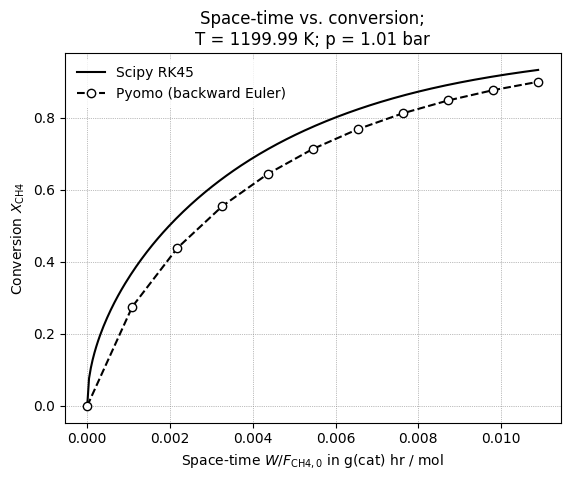

In [68]:
_ = plot_optimization_result_space_time_reforming(instance.reformer)

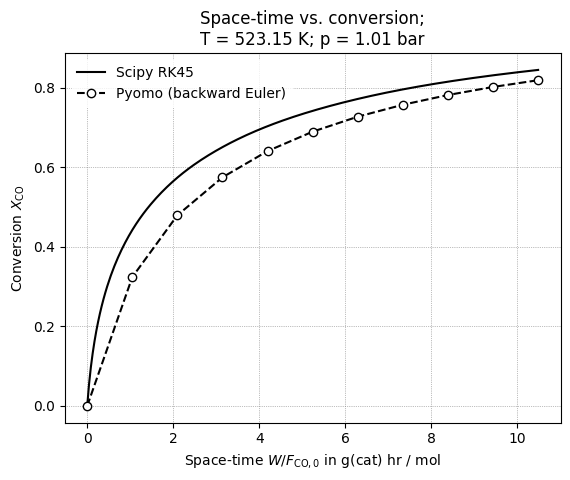

In [69]:
_ = plot_optimization_result_space_time_shift(instance.shift)

##### Fuel cell operation
[back](#Table-of-contents)

In [70]:
from phdtools.plots.optimization.postprocessing import (
    plot_optimization_result_fuel_cell,
)

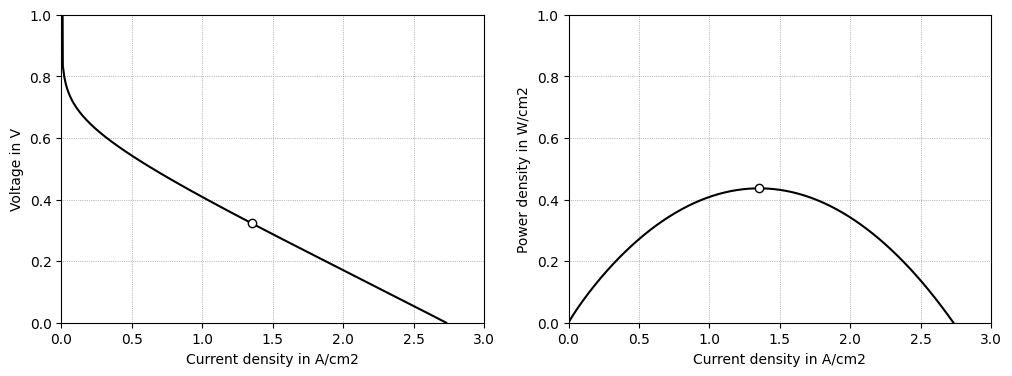

In [71]:
_ = plot_optimization_result_fuel_cell(instance.fuel_cell)

### DM-1: Parameter sweep
[back](#Table-of-contents)

In [72]:
df = pd.read_csv(
    DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)
    / f"{FILE_DATE}_profit_maximization_solution_summary.csv",
    index_col=0,
    comment="#",
)
df.loc["Markup", "1"]

np.float64(2.501012120064366)

In [73]:
import yaml

In [74]:
tmpdir = TMP_DIR / "demand_maximization_markup_runs"

markupRange = np.array([1.5, 1.75, 2.0, 2.25, 2.5, df.loc["Markup", "1"]])

if not os.path.exists(tmpdir):
    os.makedirs(tmpdir)

    run_id = 1
    for markup in markupRange:

        create_case(
            run_id=run_id,
            model_variant="demand_maximization_markup",
            markup=markup,
            fname_s=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
                / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv"
            ),
            fname_logit_coefs=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
                / f"{FILE_DATE_REGRESSION}_logit_coefficients.json"
            ),
            fname_heat=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                / f"{FILE_DATE_AGENTS}_annual_heating_demands_{NUM_AGENTS}.csv"
            ),
            fname_electricity=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                / f"{FILE_DATE_AGENTS}_annual_electricity_demands_{NUM_AGENTS}.csv"
            ),
            fname_cost_coefs=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
                / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
            ),
            outdir=tmpdir,
        )

        config = {
            "model": {
                "filename": f"{PROJECT_ROOT}/phdtools/optimization/pyomo/demand_maximization_markup.py"
            },
            "data": {"files": [f"demand_maximization_markup_{run_id}.dat"]},
            "runtime": {
                "logging": "quiet",
                "logfile": f"demand_maximization_markup_{run_id}.log",
                "stream output": True,
            },
            "solvers": [
                {
                    "solver name": "scip",
                    "options": {"limits/time": TIME_LIMIT_SECONDS},
                }
            ],
            "postsolve": {"save results": f"results_{run_id}.yaml"},
        }

        with open(tmpdir / f"demand_maximization_markup_{run_id}.yaml", "w") as f:
            yaml.dump(config, f, sort_keys=False)

        run_id += 1

In [75]:
if (os.path.exists(tmpdir)) and (not list(tmpdir.glob("results*"))):
    !TMPDIR={tmpdir} && source ./solve_cases.sh

In [76]:
!ls {tmpdir}

base.dat                          demand_maximization_markup_5.log
consumer_preferences.dat          demand_maximization_markup_5.yaml
demand_maximization_markup_1.dat  demand_maximization_markup_6.dat
demand_maximization_markup_1.log  demand_maximization_markup_6.log
demand_maximization_markup_1.yaml demand_maximization_markup_6.yaml
demand_maximization_markup_2.dat  fuel_cell.dat
demand_maximization_markup_2.log  reformer.dat
demand_maximization_markup_2.yaml results_1.yaml
demand_maximization_markup_3.dat  results_2.yaml
demand_maximization_markup_3.log  results_3.yaml
demand_maximization_markup_3.yaml results_4.yaml
demand_maximization_markup_4.dat  results_5.yaml
demand_maximization_markup_4.log  results_6.yaml
demand_maximization_markup_4.yaml shift.dat
demand_maximization_markup_5.dat


In [77]:
data_id = DataID(DataType.SUPPORT, Chapter.RESULTS, 3)

save_optimization_results(
    data_id=data_id,
    source_dir=TMP_DIR / "demand_maximization_markup_runs",
    doc=(r"Demand maximization results for different values of constant markup."),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/dO4twu' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [78]:
!ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 3).get_path(fail_exists=False)}

base.dat                          demand_maximization_markup_5.log
consumer_preferences.dat          demand_maximization_markup_5.yaml
demand_maximization_markup_1.dat  demand_maximization_markup_6.dat
demand_maximization_markup_1.log  demand_maximization_markup_6.log
demand_maximization_markup_1.yaml demand_maximization_markup_6.yaml
demand_maximization_markup_2.dat  fuel_cell.dat
demand_maximization_markup_2.log  reformer.dat
demand_maximization_markup_2.yaml results_1.yaml
demand_maximization_markup_3.dat  results_2.yaml
demand_maximization_markup_3.log  results_3.yaml
demand_maximization_markup_3.yaml results_4.yaml
demand_maximization_markup_4.dat  results_5.yaml
demand_maximization_markup_4.log  results_6.yaml
demand_maximization_markup_4.yaml shift.dat
demand_maximization_markup_5.dat


#### DM-1: Solution summary
[back](#Table-of-contents)

In [79]:
data_id = DataID(DataType.TABLE, Chapter.RESULTS, 3)

create_solution_summary(
    data_id=data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 3),
    ffname=r"demand_maximization_markup_{}.dat",
    outname=f"{TODAY}_demand_maximization_markup_solution_summary.csv",
    description=(
        f"Solution summary for the demand maximization problem with constant markups. \n"
        f"For parameter values and solver configurations see: {DataID(DataType.SUPPORT, Chapter.RESULTS, 3).to_sqid()}"
    ),
    doc=(
        r"Solution summary for the demand maximization problem with constant markups."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/0dTLt9' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [80]:
!ls {DataID(DataType.TABLE, Chapter.RESULTS, 3).get_path(fail_exists=False)}

260419_demand_maximization_markup_solution_summary.csv


In [84]:
df = pd.read_csv(
    DataID(DataType.TABLE, Chapter.RESULTS, 3).get_path(fail_exists=False)
    / f"{FILE_DATE}_demand_maximization_markup_solution_summary.csv",
    index_col=0,
    comment="#",
)
df

,1,2,3,4,5,6
RUN_ID,,,,,,
Normalized total contribution (Euro),2456.809568,3495.129701,4407.762856,5196.898364,5866.036315,5868.507023
Market share (percent),52.782296,50.096160,47.411063,44.741983,42.103614,42.093012
Price (Euro),13963.827480,16279.296958,18593.815758,20907.470768,23220.636652,23230.000945
Variable costs (Euro),9309.218320,9302.455405,9296.907879,9292.209230,9288.254661,9288.240052
Contribution margin (Euro),4654.609160,6976.841553,9296.907879,11615.261538,13932.381991,13941.760892
Markup,1.500000,1.750000,2.000000,2.250000,2.500000,2.501012
Sample mean energy cost savings (percent),9.432597,9.406455,9.381762,9.358097,9.335885,9.335793
Sample mean CO2 savings (percent),12.843392,12.814969,12.788122,12.762393,12.738242,12.738141
Thermal power (kW),12.500000,12.500000,12.500000,12.500000,12.500000,12.500000


#### DM-1: Solution statistics
[back](#Table-of-contents)

In [85]:
from pyomo.opt import SolverResults, SolverStatus

In [86]:
# request_free_id(DataType.SUPPORT, Chapter.RESULTS)

In [87]:
!ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 3).get_path(fail_exists=False)}

base.dat                          demand_maximization_markup_5.log
consumer_preferences.dat          demand_maximization_markup_5.yaml
demand_maximization_markup_1.dat  demand_maximization_markup_6.dat
demand_maximization_markup_1.log  demand_maximization_markup_6.log
demand_maximization_markup_1.yaml demand_maximization_markup_6.yaml
demand_maximization_markup_2.dat  fuel_cell.dat
demand_maximization_markup_2.log  reformer.dat
demand_maximization_markup_2.yaml results_1.yaml
demand_maximization_markup_3.dat  results_2.yaml
demand_maximization_markup_3.log  results_3.yaml
demand_maximization_markup_3.yaml results_4.yaml
demand_maximization_markup_4.dat  results_5.yaml
demand_maximization_markup_4.log  results_6.yaml
demand_maximization_markup_4.yaml shift.dat
demand_maximization_markup_5.dat


In [88]:
data_id = DataID(DataType.TABLE, Chapter.RESULTS, 6)


@auto_create_path
def save_demand_maximization_markup_solution_statistics(path, results_id):
    pathlist = list(results_id.get_path(fail_exists=False).glob("results*"))

    run_ids = np.zeros(len(pathlist), dtype=int)

    markupValues = np.full(len(pathlist), np.nan)

    solverTimeValues = np.full(len(pathlist), np.nan)
    solverNodeCountValues = np.zeros(len(pathlist), dtype=int)
    solverPrimalBoundValues = np.full(len(pathlist), np.nan)
    solverDualBoundValues = np.full(len(pathlist), np.nan)
    solverGapValues = np.full(len(pathlist), np.nan)

    for num, pth in enumerate(pathlist):
        if pth.is_file():
            results = SolverResults()
            results.read(filename=pth)
            run_id = pth.stem.split("_")[-1]

            if (results.solver.status == SolverStatus.ok) and (
                results.solver.termination_condition
                != pyo.TerminationCondition.infeasible
            ):
                run_ids[num] = int(run_id)
                solverTimeValues[num] = results.solver.time
                solverNodeCountValues[num] = int(results.solver.node_count)
                solverPrimalBoundValues[num] = results.solver.primal_bound
                solverDualBoundValues[num] = results.solver.dual_bound
                solverGapValues[num] = results.solver.Gap

                with chdir(results_id.get_path(fail_exists=False)):
                    dp = pyo.DataPortal(
                        filename=f"demand_maximization_markup_{run_id}.dat"
                    )

                instance = pyomo_load_solution(pth, model=model, modeldata=dp)

                markupValues[num] = pyo.value(instance.MARKUP)

    df = (
        pd.DataFrame(
            {
                "RUN_ID": run_ids,
                "Markup": markupValues,
                "Time (sec)": solverTimeValues,
                "Nodes": solverNodeCountValues,
                "Primal bound": solverPrimalBoundValues,
                "Dual bound": solverDualBoundValues,
                "Gap (percent)": solverGapValues,
            },
        )
        .set_index("RUN_ID")
        .sort_index()
    )

    df.drop_duplicates()

    frame = df.copy()  # .drop("epsThermalEfficiency",axis=1)
    frame["Primal bound"] = np.round(df["Primal bound"] * 1e4) / 1e4
    frame["Dual bound"] = np.round(df["Dual bound"] * 1e4) / 1e4

    frame = frame.drop_duplicates()

    description = (
        r"Solver statistics for the demand maximization problem with constant markups (using \SCIP{}); \n"
        f"For parameter values and solver configurations see: {results_id.to_sqid()}"
    )

    fname = path / f"{TODAY}_demand_maximization_markup_solver_statistics.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        frame.T.to_csv(f, index_label="RUN_ID")


save_demand_maximization_markup_solution_statistics(
    data_id=data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 3),
    doc=(
        rf"Solver statistics for the demand maximization problem with constant markups (using \SCIP{{}}); "
        rf"For parameter values and solver configurations see: \texttt{{{DataID(DataType.SUPPORT, Chapter.RESULTS, 1).to_sqid()}}}"
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/L5pVHe' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [89]:
!ls {DataID(DataType.TABLE, Chapter.RESULTS, 6).get_path(fail_exists=False)}

260419_demand_maximization_markup_solver_statistics.csv


In [90]:
df = pd.read_csv(
    DataID(DataType.TABLE, Chapter.RESULTS, 6).get_path(fail_exists=False)
    / f"{FILE_DATE}_demand_maximization_markup_solver_statistics.csv",
    index_col=0,
    comment="#",
)
df

,1,2,3,4,5,6
RUN_ID,,,,,,
Markup,1.5000,1.7500,2.0000,2.2500,2.5000,2.501012
Time (sec),30.0000,30.0000,30.0000,30.0000,30.0000,30.000000
Nodes,204.0000,509.0000,605.0000,352.0000,275.0000,276.000000
Primal bound,0.5278,0.5010,0.4741,0.4474,0.4210,0.420900
Dual bound,0.5565,0.5311,0.5056,0.4801,0.4547,0.454600
Gap (percent),5.4200,6.0200,6.6500,7.3000,7.9900,7.990000


## Demand maximization with constant contribution
[back](#Table-of-contents)

### DM-2: Example
[back](#Table-of-contents)

#### DM-2: Generate case
[back](#Table-of-contents)

In [91]:
import os

run_id = 1

outdir = TMP_DIR / "test"
if not os.path.exists(outdir):
    os.makedirs(outdir)

create_case(
    run_id=run_id,
    model_variant="demand_maximization_contribution",
    contribution=14000,
    fname_s=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
        / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv"
    ),
    fname_logit_coefs=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
        / f"{FILE_DATE_REGRESSION}_logit_coefficients.json"
    ),
    fname_heat=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE_AGENTS}_annual_heating_demands_{NUM_AGENTS}.csv"
    ),
    fname_electricity=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE_AGENTS}_annual_electricity_demands_{NUM_AGENTS}.csv"
    ),
    fname_cost_coefs=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
        / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
    ),
    outdir=outdir,
)

/Users/marvinmeck/test/phd-tools/phdtools/models/meck_2025.py:550: RuntimeWarning: divide by zero encountered in log
  + R * T / F * (1 / 4 + 1 / a) * np.log(1 - j / jL)


#### DM-2: Problem statistics
[back](#Table-of-contents)

In [92]:
!ls {outdir}

base.dat                               reformer.dat
consumer_preferences.dat               results_1.yml
cost_minimization_1.dat                results_2.yml
demand_maximization_contribution_1.dat results_3.yml
demand_maximization_markup_1.dat       shift.dat
fuel_cell.dat


In [93]:
from phdtools.optimization.pyomo.demand_maximization_contribution import (
    create_abstract_model,
)

model = create_abstract_model()

with chdir(outdir):
    dp = pyo.DataPortal(filename=f"demand_maximization_contribution_1.dat")

    model.reformer.construct(dp.data(namespace="reformer"))
    model.shift.construct(dp.data(namespace="shift"))
    model.fuel_cell.construct(dp.data(namespace="fuel_cell"))
    instance = model.create_instance(dp, namespace=None)

In [94]:
report = build_model_size_report(instance)

print(report)

activated:
    binary_variables: 0
    constraints: 339
    continuous_variables: 326
    disjunctions: 0
    disjuncts: 0
    integer_variables: 0
    nonlinear_constraints: 182
    variables: 326
overall:
    binary_variables: 0
    constraints: 339
    continuous_variables: 326
    disjunctions: 0
    disjuncts: 0
    integer_variables: 0
    nonlinear_constraints: 182
    variables: 326
    unassociated_disjuncts: 0


In [95]:
stats = create_pyomo_problem_statistics(instance)

pprint(stats)

{'constraints': {'linear': 157,
                 'non-polynomial nonlinear': 49,
                 'polynomial': 0,
                 'quadratic': 133,
                 'total': 339},
 'variables': {'binary': 0, 'continuous': 326, 'integer': 0, 'total': 326}}


#### DM-2: Solve case
[back](#Table-of-contents)

In [96]:
!ls {outdir}

base.dat                               reformer.dat
consumer_preferences.dat               results_1.yml
cost_minimization_1.dat                results_2.yml
demand_maximization_contribution_1.dat results_3.yml
demand_maximization_markup_1.dat       shift.dat
fuel_cell.dat


In [97]:
!cd {outdir} && pyomo solve --solver=scip --solver-options="limits/time=30" --save-results=results_3.yml --stream-output {PROJECT_ROOT}/phdtools/optimization/pyomo/demand_maximization_contribution.py demand_maximization_contribution_1.dat

[    0.00] Setting up Pyomo environment
[    0.00] Applying Pyomo preprocessing actions
[    1.18] Creating model
[    1.20] Applying solver
SCIP version 10.0.1 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.1] [GitHash: 76a50c97d6]
Copyright (c) 2002-2026 Zuse Institute Berlin (ZIB)

External libraries: 
  Readline 8.3         GNU library for command line editing (gnu.org/s/readline)
  SoPlex 8.0.1         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: c69290aa]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.2.12          General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.2           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.90.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP

#### DM-2: Verification
[back](#Table-of-contents)

In [98]:
!ls {outdir}

base.dat                               reformer.dat
consumer_preferences.dat               results_1.yml
cost_minimization_1.dat                results_2.yml
demand_maximization_contribution_1.dat results_3.yml
demand_maximization_markup_1.dat       shift.dat
fuel_cell.dat


In [99]:
from phdtools.optimization.postprocessing import pyomo_load_solution
from phdtools.optimization.pyomo.demand_maximization_contribution import (
    create_abstract_model,
)

fname = os.path.join(outdir, "results_3.yml")
model = create_abstract_model()

with chdir(outdir):
    dp = pyo.DataPortal(filename=f"demand_maximization_contribution_1.dat")

instance = pyomo_load_solution(fname, model=model, modeldata=dp)

WARNING (W1002): Setting Var 'electricalPowerScaled' to a numeric value
`1.0000000039867558` outside the bounds (0.3, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'variableCostsScaled' to a numeric value
`1.0000000232157906` outside the bounds (0.9456927893208237, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'investmentCostsScaled' to a numeric value
`1.00000000928256` outside the bounds (0.37812410487944864, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'priceScaled' to a numeric value
`1.00000000928256` outside the bounds (0.3781241048794486, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'fuel_cell.powerDensityScaled' to a numeric value
`1.000000008162042` outside the bounds (0, 1).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w100

##### Explanatory variables
[back](#Table-of-contents)

In [100]:
priceEuro = pyo.value(instance.priceEuro)
thermalEfficiency = pyo.value(instance.thermalEfficiency)
powerIndex = pyo.value(instance.powerIndex)
matchingFactor = pyo.value(instance.MATCHING_FACTOR)

index = pd.Index([1], name="ALTERNATIVE")
designs = pd.DataFrame(
    [[priceEuro, thermalEfficiency, powerIndex, matchingFactor]],
    columns=["PRICE_EURO", "THERMAL_EFFICIENCY", "POWER_INDEX", "MATCHING_FACTOR"],
    index=index,
)

attributes_alternative = get_attributes_alternative(
    designs,
    data_id_socio_demographic_attributes=DataID(DataType.SUPPORT, Chapter.METHODS, 1),
    data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
    data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
    file_date=FILE_DATE_DEMANDS,
    file_date_agents=FILE_DATE_AGENTS,
    sample_size=NUM_AGENTS,
    fit=100 * FEED_IN_TARIFF_EUR_PER_KWH,
    itype=INVESTMENT_TYPE,
    dur=CONTRACT_DURATION_YEARS,
)

attributes_alternative

,,ICOST,CSAV,CO2SAV,FIT,ITYPE,DUR
AGENT,ALTERNATIVE,,,,,,
1,1,30.325156,11.971289,1.502130,8.0,0,5
5,1,30.325156,9.321614,1.232692,8.0,0,5
6,1,30.325156,6.268267,0.883804,8.0,0,5
11,1,30.325156,8.441377,1.136639,8.0,0,5
12,1,30.325156,10.081023,1.312838,8.0,0,5
13,1,30.325156,10.520164,1.358081,8.0,0,5
14,1,30.325156,9.797653,1.604768,8.0,0,5


In [101]:
attributes_alternative_pyomo = pd.DataFrame(
    {
        "ICOST": {n: pyo.value(instance.icost) for n in instance.setAgents},
        "CSAV": {n: pyo.value(instance.csav[n]) for n in instance.setAgents},
        "CO2SAV": {n: pyo.value(instance.co2sav[n]) for n in instance.setAgents},
        "FIT": {n: pyo.value(instance.FIT) for n in instance.setAgents},
        "ITYPE": {n: pyo.value(instance.ITYPE) for n in instance.setAgents},
        "DUR": {n: pyo.value(instance.DUR) for n in instance.setAgents},
    },
    index=pd.Index(instance.setAgents, name="AGENT"),
)

attributes_alternative_pyomo

,ICOST,CSAV,CO2SAV,FIT,ITYPE,DUR
AGENT,,,,,,
1,30.325156,11.971289,1.502130,8.0,0,5
5,30.325156,9.321614,1.232692,8.0,0,5
6,30.325156,6.268268,0.883804,8.0,0,5
11,30.325156,8.441378,1.136639,8.0,0,5
12,30.325156,10.081024,1.312838,8.0,0,5
13,30.325156,10.520165,1.358081,8.0,0,5
14,30.325156,9.797653,1.604768,8.0,0,5


##### Probability
[back](#Table-of-contents)

In [102]:
pyo.value(instance.obj)

0.4205521077377817

In [103]:
from phdtools.models.rommel_sagebiel_2017 import compute_sample_avg_logit_prob

sample_average_logit_probabilities = compute_sample_avg_logit_prob(
    attributes_alternative,
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv",
    fname_c=DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
    / f"{FILE_DATE_REGRESSION}_logit_coefficients.json",
)

sample_average_logit_probabilities

ALTERNATIVE
1    0.420552
Name: SAMPLE_AVG_LOGIT_PROB, dtype: float64

In [104]:
assert np.isclose(
    pyo.value(instance.marketShare), sample_average_logit_probabilities.iloc[0]
)

##### Space-time vs. conversion
[back](#Table-of-contents)

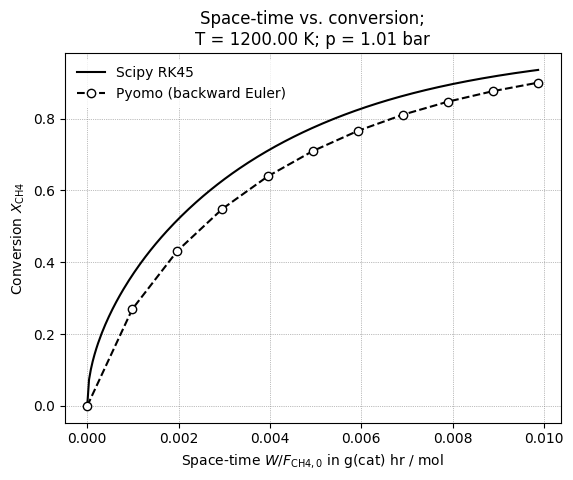

In [105]:
_ = plot_optimization_result_space_time_reforming(instance.reformer)

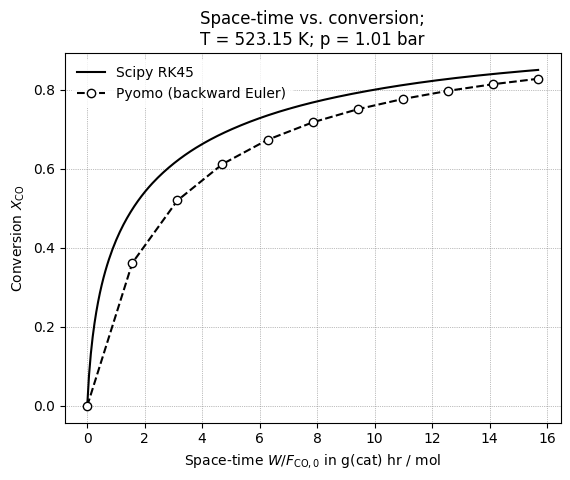

In [106]:
_ = plot_optimization_result_space_time_shift(instance.shift)

##### Fuel cell operation
[back](#Table-of-contents)

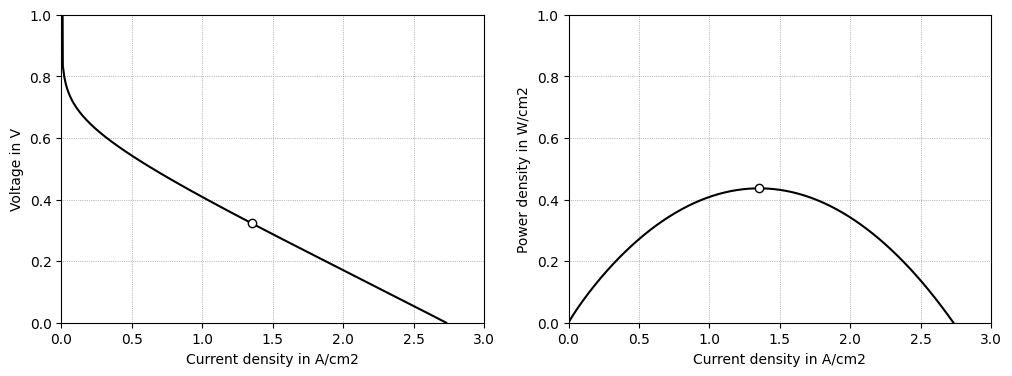

In [107]:
_ = plot_optimization_result_fuel_cell(instance.fuel_cell)

### DM-2: Parameter sweep
[back](#Table-of-contents)

In [108]:
df = pd.read_csv(
    DataID(DataType.TABLE, Chapter.RESULTS, 3).get_path(fail_exists=False)
    / f"{FILE_DATE}_demand_maximization_markup_solution_summary.csv",
    index_col=0,
    comment="#",
)

df.loc[["Markup", "Contribution margin (Euro)"]]

,1,2,3,4,5,6
RUN_ID,,,,,,
Markup,1.50000,1.750000,2.000000,2.250000,2.500000,2.501012
Contribution margin (Euro),4654.60916,6976.841553,9296.907879,11615.261538,13932.381991,13941.760892


In [109]:
tmpdir = TMP_DIR / "demand_maximization_contribution_runs"

contributionRange = np.array(
    [*df.loc["Contribution margin (Euro)"].to_numpy()[:-1], 14000]
)

if not os.path.exists(tmpdir):
    os.makedirs(tmpdir)

    run_id = 1
    for contribution in contributionRange:

        create_case(
            run_id=run_id,
            model_variant="demand_maximization_contribution",
            contribution=contribution,
            fname_s=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
                / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv"
            ),
            fname_logit_coefs=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
                / f"{FILE_DATE_REGRESSION}_logit_coefficients.json"
            ),
            fname_heat=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                / f"{FILE_DATE_AGENTS}_annual_heating_demands_{NUM_AGENTS}.csv"
            ),
            fname_electricity=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                / f"{FILE_DATE_AGENTS}_annual_electricity_demands_{NUM_AGENTS}.csv"
            ),
            fname_cost_coefs=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
                / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
            ),
            outdir=tmpdir,
        )

        config = {
            "model": {
                "filename": f"{PROJECT_ROOT}/phdtools/optimization/pyomo/demand_maximization_contribution.py"
            },
            "data": {"files": [f"demand_maximization_contribution_{run_id}.dat"]},
            "runtime": {
                "logging": "quiet",
                "logfile": f"demand_maximization_contribution_{run_id}.log",
                "stream output": True,
            },
            "solvers": [
                {
                    "solver name": "scip",
                    "options": {"limits/time": TIME_LIMIT_SECONDS},
                }
            ],
            "postsolve": {"save results": f"results_{run_id}.yaml"},
        }

        with open(tmpdir / f"demand_maximization_contribution_{run_id}.yaml", "w") as f:
            yaml.dump(config, f, sort_keys=False)

        run_id += 1

In [110]:
if (os.path.exists(tmpdir)) and (not list(tmpdir.glob("results*"))):
    !TMPDIR={tmpdir} && source ./solve_cases.sh

In [111]:
!ls {tmpdir}

base.dat                                demand_maximization_contribution_5.log
consumer_preferences.dat                demand_maximization_contribution_5.yaml
demand_maximization_contribution_1.dat  demand_maximization_contribution_6.dat
demand_maximization_contribution_1.log  demand_maximization_contribution_6.log
demand_maximization_contribution_1.yaml demand_maximization_contribution_6.yaml
demand_maximization_contribution_2.dat  fuel_cell.dat
demand_maximization_contribution_2.log  reformer.dat
demand_maximization_contribution_2.yaml results_1.yaml
demand_maximization_contribution_3.dat  results_2.yaml
demand_maximization_contribution_3.log  results_3.yaml
demand_maximization_contribution_3.yaml results_4.yaml
demand_maximization_contribution_4.dat  results_5.yaml
demand_maximization_contribution_4.log  results_6.yaml
demand_maximization_contribution_4.yaml shift.dat
demand_maximization_contribution_5.dat


In [112]:
data_id = DataID(DataType.SUPPORT, Chapter.RESULTS, 4)

save_optimization_results(
    data_id=data_id,
    source_dir=TMP_DIR / "demand_maximization_contribution_runs",
    doc=(r"Demand maximization results for different values of constant contribution."),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/YhEbTd' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [113]:
!ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 4).get_path(fail_exists=False)}

base.dat                                demand_maximization_contribution_5.log
consumer_preferences.dat                demand_maximization_contribution_5.yaml
demand_maximization_contribution_1.dat  demand_maximization_contribution_6.dat
demand_maximization_contribution_1.log  demand_maximization_contribution_6.log
demand_maximization_contribution_1.yaml demand_maximization_contribution_6.yaml
demand_maximization_contribution_2.dat  fuel_cell.dat
demand_maximization_contribution_2.log  reformer.dat
demand_maximization_contribution_2.yaml results_1.yaml
demand_maximization_contribution_3.dat  results_2.yaml
demand_maximization_contribution_3.log  results_3.yaml
demand_maximization_contribution_3.yaml results_4.yaml
demand_maximization_contribution_4.dat  results_5.yaml
demand_maximization_contribution_4.log  results_6.yaml
demand_maximization_contribution_4.yaml shift.dat
demand_maximization_contribution_5.dat


### DM-2: Solution summary
[back](#Table-of-contents)

In [114]:
data_id = DataID(DataType.TABLE, Chapter.RESULTS, 4)


create_solution_summary(
    data_id=data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 4),
    outname=f"{TODAY}_demand_maximization_contribution_solution_summary.csv",
    ffname=r"demand_maximization_contribution_{}.dat",
    description=(
        f"Solution summary for the demand maximization problem with constant contribution. \n"
        f"For parameter values and solver configurations see: {DataID(DataType.SUPPORT, Chapter.RESULTS, 3).to_sqid()}"
    ),
    doc=(
        r"Solution summary for the demand maximization problem with constant contribution."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/zYcDwP' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [115]:
!ls {DataID(DataType.TABLE, Chapter.RESULTS, 4).get_path(fail_exists=False)}

260419_demand_maximization_contribution_solution_summary.csv


In [116]:
df = pd.read_csv(
    DataID(DataType.TABLE, Chapter.RESULTS, 4).get_path(fail_exists=False)
    / f"{FILE_DATE}_demand_maximization_contribution_solution_summary.csv",
    index_col=0,
    comment="#",
)
df

,1,2,3,4,5,6
RUN_ID,,,,,,
Normalized total contribution (Euro),2457.050845,3495.836856,4409.231436,5199.435258,5869.913638,5887.729508
Market share (percent),52.787479,50.106296,47.426859,44.763824,42.131443,42.055211
Price (Euro),13981.652132,16303.884543,18623.950854,20942.304513,23259.424892,23327.043116
Variable costs (Euro),9327.042972,9327.042989,9327.042975,9327.042976,9327.042900,9327.043116
Contribution margin (Euro),4654.609160,6976.841553,9296.907879,11615.261538,13932.381991,14000.000000
Markup,1.499044,1.748023,1.996769,2.245332,2.493762,2.501012
Sample mean energy cost savings (percent),9.485913,9.485913,9.485913,9.485913,9.485912,9.485913
Sample mean CO2 savings (percent),12.901358,12.901358,12.901358,12.901358,12.901358,12.901359
Thermal power (kW),12.500000,12.500000,12.500000,12.500000,12.500000,12.500000


#### DM-2: Solution statistics
[back](#Table-of-contents)

In [117]:
# request_free_id(DataType.SUPPORT, Chapter.RESULTS)

In [118]:
data_id = DataID(DataType.TABLE, Chapter.RESULTS, 7)


@auto_create_path
def save_demand_maximization_contribution_solution_statistics(path, results_id):
    pathlist = list(results_id.get_path(fail_exists=False).glob("results*"))

    run_ids = np.zeros(len(pathlist), dtype=int)

    contributionValues = np.full(len(pathlist), np.nan)

    solverTimeValues = np.full(len(pathlist), np.nan)
    solverNodeCountValues = np.zeros(len(pathlist), dtype=int)
    solverPrimalBoundValues = np.full(len(pathlist), np.nan)
    solverDualBoundValues = np.full(len(pathlist), np.nan)
    solverGapValues = np.full(len(pathlist), np.nan)

    for num, pth in enumerate(pathlist):
        if pth.is_file():
            results = SolverResults()
            results.read(filename=pth)
            run_id = pth.stem.split("_")[-1]

            if (results.solver.status == SolverStatus.ok) and (
                results.solver.termination_condition
                != pyo.TerminationCondition.infeasible
            ):
                run_ids[num] = int(run_id)
                solverTimeValues[num] = results.solver.time
                solverNodeCountValues[num] = int(results.solver.node_count)
                solverPrimalBoundValues[num] = results.solver.primal_bound
                solverDualBoundValues[num] = results.solver.dual_bound
                solverGapValues[num] = results.solver.Gap

                with chdir(results_id.get_path(fail_exists=False)):
                    dp = pyo.DataPortal(
                        filename=f"demand_maximization_contribution_{run_id}.dat"
                    )

                instance = pyomo_load_solution(pth, model=model, modeldata=dp)

                contributionValues[num] = pyo.value(instance.CONTRIBUTION_MARGIN_EURO)

    df = (
        pd.DataFrame(
            {
                "RUN_ID": run_ids,
                "Contribution margin (Euro)": contributionValues,
                "Time (sec)": solverTimeValues,
                "Nodes": solverNodeCountValues,
                "Primal bound": solverPrimalBoundValues,
                "Dual bound": solverDualBoundValues,
                "Gap (percent)": solverGapValues,
            },
        )
        .set_index("RUN_ID")
        .sort_index()
    )

    df.drop_duplicates()

    frame = df.copy()  # .drop("epsThermalEfficiency",axis=1)
    frame["Primal bound"] = np.round(df["Primal bound"] * 1e4) / 1e4
    frame["Dual bound"] = np.round(df["Dual bound"] * 1e4) / 1e4

    frame = frame.drop_duplicates()

    description = (
        r"Solver statistics for the demand maximization problem with constant markups (using \SCIP{}); \n"
        f"For parameter values and solver configurations see: {results_id.to_sqid()}"
    )

    fname = path / f"{TODAY}_demand_maximization_contribution_solver_statistics.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        frame.T.to_csv(f, index_label="RUN_ID")


save_demand_maximization_contribution_solution_statistics(
    data_id=data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 4),
    doc=(
        rf"Solver statistics for the demand maximization problem with constant contribution (using \SCIP{{}}); "
        rf"For parameter values and solver configurations see: \texttt{{{DataID(DataType.SUPPORT, Chapter.RESULTS, 1).to_sqid()}}}"
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/mixp3T' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [119]:
!ls {DataID(DataType.TABLE, Chapter.RESULTS, 7).get_path(fail_exists=False)}

260419_demand_maximization_contribution_solver_statistics.csv


In [120]:
df = pd.read_csv(
    DataID(DataType.TABLE, Chapter.RESULTS, 7).get_path(fail_exists=False)
    / f"{FILE_DATE}_demand_maximization_contribution_solver_statistics.csv",
    index_col=0,
    comment="#",
)
df

,1,2,3,4,5,6
RUN_ID,,,,,,
Contribution margin (Euro),4654.60916,6976.841553,9296.907879,11615.261538,13932.381991,14000.0000
Time (sec),30.00000,30.000000,30.000000,30.000000,30.000000,30.0000
Nodes,289.00000,217.000000,445.000000,196.000000,48.000000,200.0000
Primal bound,0.52790,0.501100,0.474300,0.447600,0.421300,0.4206
Dual bound,0.55390,0.527300,0.500600,0.473900,0.428600,0.4465
Gap (percent),4.93000,5.230000,5.550000,5.860000,1.720000,6.1800


## Comparison of optimization results
[back](#Table-of-contents)

In [121]:
df = pd.read_csv(
    DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)
    / f"{FILE_DATE}_profit_maximization_solution_summary.csv",
    index_col=0,
    comment="#",
)
df.loc["Markup", "1"]

np.float64(2.501012120064366)

In [122]:
from phdtools.optimization.postprocessing import (
    calculate_consumer_preferences_cost_optimization_constant_markup,
)

df = calculate_consumer_preferences_cost_optimization_constant_markup(
    fname_results_summary=DataID(DataType.TABLE, Chapter.RESULTS, 1).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE_COST_MINIMIZATION}_cost_minimization_solution_summary.csv",
    markup=df.loc["Markup", "1"],
    fname_heat=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE_DEMANDS}_annual_heating_demands_{16}.csv"
    ),
    fname_electricity=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE_DEMANDS}_annual_electricity_demands_{16}.csv"
    ),
    data_id_socio_demographic_attributes=DataID(DataType.SUPPORT, Chapter.METHODS, 1),
    data_id_mxl_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 2),
    data_id_logit_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 3),
    data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
    data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
    file_date_agents=FILE_DATE_AGENTS,
    file_date_sample=FILE_DATE_SAMPLE,
    file_date_demands=FILE_DATE_DEMANDS,
    file_date_logit_regression=FILE_DATE_REGRESSION,
    num_agents=NUM_AGENTS,
    mxl_coefs_sample_size=MXL_COEFS_SMAPLE_SIZE,
)
df.head(8)

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
RUN_ID,,,,,,,,,,,,,,,
"Normalized total contribution, MXL (Euro)",5820.094080,5841.911185,5863.733901,5885.561825,5907.394585,5929.231808,5949.852130,5969.162174,5988.476438,6007.794667,6027.116568,6046.442007,6065.770621,6085.102207,6104.436532
"Normalized total contribution, MNL (Euro)",5596.627015,5616.458068,5636.318699,5656.208862,5676.128521,5696.077629,5714.488960,5731.229497,5747.982026,5764.746550,5781.523025,5798.311584,5815.112096,5831.924606,5848.749118
"Market share, MXL (percent)",43.374263,43.424314,43.474149,43.523768,43.573169,43.622351,43.662354,43.692563,43.722651,43.752616,43.782459,43.812177,43.841770,43.871238,43.900579
"Market share, MNL (percent)",41.708874,41.748467,41.788076,41.827701,41.867341,41.906997,41.935166,41.950964,41.966770,41.982584,41.998407,42.014238,42.030077,42.045925,42.061781
Price (Euro),22357.822039,22415.766074,22473.709516,22531.652284,22589.594418,22647.535910,22705.476769,22763.416995,22821.356594,22879.295566,22937.233891,22995.171648,23053.108762,23111.045261,23168.981165
Variable costs (Euro),8939.509673,8962.677907,8985.845905,9009.013632,9032.181106,9055.348324,9078.515288,9101.682000,9124.848461,9148.014671,9171.180622,9194.346346,9217.511813,9240.677034,9263.842018
Contribution margin (Euro),13418.312366,13453.088167,13487.863612,13522.638652,13557.413311,13592.187586,13626.961480,13661.734995,13696.508133,13731.280896,13766.053269,13800.825302,13835.596949,13870.368226,13905.139147
Markup,2.501012,2.501012,2.501012,2.501012,2.501012,2.501012,2.501012,2.501012,2.501012,2.501012,2.501012,2.501012,2.501012,2.501012,2.501012


In [123]:
def update_cost_minimization_market_shares_and_contribution(
    data_id, markup, overwrite=False
):

    if overwrite:
        df = calculate_consumer_preferences_cost_optimization_constant_markup(
            fname_results_summary=DataID(DataType.TABLE, Chapter.RESULTS, 1).get_path(
                fail_exists=False
            )
            / f"{FILE_DATE_COST_MINIMIZATION}_cost_minimization_solution_summary.csv",
            fname_heat=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                / f"{FILE_DATE_DEMANDS}_annual_heating_demands_{16}.csv"
            ),
            fname_electricity=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                / f"{FILE_DATE_DEMANDS}_annual_electricity_demands_{16}.csv"
            ),
            data_id_socio_demographic_attributes=DataID(
                DataType.SUPPORT, Chapter.METHODS, 1
            ),
            data_id_mxl_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 2),
            data_id_logit_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 3),
            data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
            data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
            file_date_agents=FILE_DATE_AGENTS,
            file_date_sample=FILE_DATE_SAMPLE,
            file_date_demands=FILE_DATE_DEMANDS,
            file_date_logit_regression=FILE_DATE_REGRESSION,
            num_agents=NUM_AGENTS,
            mxl_coefs_sample_size=MXL_COEFS_SMAPLE_SIZE,
            markup=markup,
        )

        description = (
            f"Expected market share and normalized total contribution calculated for the optimal solutions \n"
            f"of the cost minimization problem assuming a pricing strategy with constant markup: \n"
            f"  Markup = Price / Variable costs = {markup}\n"
            f"The values for the MXL model (Rommel and Sagebiel, 2017) are calculated using {NUM_AGENTS} agents \n"
            f"and {MXL_COEFS_SMAPLE_SIZE} realizations of the random coefficients. \n"
            f"The values for the MNL model are calculated according to the reduced approximation used in the choice-\n"
            f"based optimization models with 16 agents. Note, that the actual sample size is further reduced since\n"
            f"decision makers with HEASTSYS = 0 are removed from the sample prior to evaluating the choice probabilities.\n\n"
            f"References:\n"
            f"-----------\n"
            f"Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            f"    Germany: Policy implications for grid expansion from a discrete choice\n"
            f"    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            f"    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
        )

        path = data_id.get_path(fail_exists=False)

        fname = path / (
            f"{TODAY}_cost_minimization_constant_markup_margin_of_profit_maximum.csv"
        )
        with open(fname, "w") as f:
            write_metadata(f, description)
            df.to_csv(f)


update_cost_minimization_market_shares_and_contribution(
    DataID(DataType.SUPPORT, Chapter.RESULTS, 2),
    markup=df.loc["Markup", "1"],
    overwrite=True,  # must be True!
)

In [124]:
!ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 2).get_path(fail_exists=False)}

260419_cost_minimization_constant_contribution_10000.csv
260419_cost_minimization_constant_contribution_10500.csv
260419_cost_minimization_constant_contribution_11000.csv
260419_cost_minimization_constant_contribution_11500.csv
260419_cost_minimization_constant_contribution_12000.csv
260419_cost_minimization_constant_contribution_12500.csv
260419_cost_minimization_constant_contribution_13000.csv
260419_cost_minimization_constant_contribution_13500.csv
260419_cost_minimization_constant_contribution_14000.csv
260419_cost_minimization_constant_contribution_14500.csv
260419_cost_minimization_constant_contribution_15000.csv
260419_cost_minimization_constant_contribution_4000.csv
260419_cost_minimization_constant_contribution_4500.csv
260419_cost_minimization_constant_contribution_5000.csv
260419_cost_minimization_constant_contribution_5500.csv
260419_cost_minimization_constant_contribution_6000.csv
260419_cost_minimization_constant_contribution_6500.csv
260419_cost_minimization_constant_con

In [125]:
from phdtools.optimization import MATCHING_FACTOR
from phdtools.optimization.postprocessing import get_sampleAverageMixedLogitProbability

In [126]:
def create_solution_comparison(
    fnames,
):
    frames = []
    for label, fname in fnames.items():
        df = pd.read_csv(
            fname,
            index_col=0,
            comment="#",
        )
        df.index.name = ""

        if label in {
            "Demand maximization with constant markup",
            "Demand maximization with constant contribution",
            "Profit maximization",
        }:
            df = df.rename(
                {
                    "Normalized total contribution (Euro)": "Normalized total contribution, MNL (Euro)",
                    "Market share (percent)": "Market share, MNL (percent)",
                }
            )

            sample_average_mxl_probabilities = get_sampleAverageMixedLogitProbability(
                priceEuro=df.loc["Price (Euro)"],
                thermalEfficiency=df.loc["Thermal efficiency"],
                powerIndex=df.loc["Electrical power (kW)"]
                / df.loc["Thermal power (kW)"],
                matchingFactor=MATCHING_FACTOR * np.ones(df.shape[1]),
                data_id_socio_demographic_attributes=DataID(
                    DataType.SUPPORT, Chapter.METHODS, 1
                ),
                data_id_mxl_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 2),
                data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
                data_id_electricity_demands=DataID(
                    DataType.SUPPORT, Chapter.METHODS, 5
                ),
                file_date_demands=FILE_DATE_DEMANDS,
                file_date_agents=FILE_DATE_AGENTS,
                file_date_sample=FILE_DATE_SAMPLE,
                num_agents=512,
                mxl_coefs_sample_size=512,
            )
            df.loc["Market share, MXL (percent)"] = (
                100 * sample_average_mxl_probabilities.values
            )
            df.loc["Normalized total contribution, MXL (Euro)"] = (
                df.loc["Price (Euro)"] - df.loc["Variable costs (Euro)"]
            ) * sample_average_mxl_probabilities.values

        df.loc["Model"] = label

        frame = (
            df.T.reset_index()
            .rename({"index": "RUN_ID"}, axis=1)
            .set_index(["Model", "RUN_ID"])
        )

        frames.append(frame)

    return pd.concat(frames)

In [127]:
summary = create_solution_comparison(
    fnames={
        "Cost minimization (markup = markup(profit max.))": DataID(
            DataType.SUPPORT, Chapter.RESULTS, 2
        ).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_constant_markup_margin_of_profit_maximum.csv",
        "Cost minimization (contribution = contribution(profit max.))": DataID(
            DataType.SUPPORT, Chapter.RESULTS, 2
        ).get_path(fail_exists=False)
        / f"{FILE_DATE_COST_MINIMIZATION}_cost_minimization_constant_contribution_14000.csv",
        "Demand maximization with constant markup": (
            DataID(DataType.TABLE, Chapter.RESULTS, 3).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_markup_solution_summary.csv"
        ),
        "Demand maximization with constant contribution": (
            DataID(DataType.TABLE, Chapter.RESULTS, 4).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_contribution_solution_summary.csv"
        ),
        "Profit maximization": (
            DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE}_profit_maximization_solution_summary.csv"
        ),
    },
)
# summary

In [128]:
summary.loc[
    [
        ("Cost minimization (contribution = contribution(profit max.))", "1"),
        ("Cost minimization (contribution = contribution(profit max.))", "15"),
        # ('Demand maximization with constant markup','6'),
        ("Demand maximization with constant contribution", "6"),
        ("Profit maximization", "1"),
    ]
].T.head(10)

Model                                     Cost minimization (contribution = contribution(profit max.))  \
RUN_ID                                                                                               1   
                                                                                                         
Normalized total contribution, MXL (Euro)                                        6147.416903             
Normalized total contribution, MNL (Euro)                                        5747.814704             
Market share, MXL (percent)                                                        43.910121             
Market share, MNL (percent)                                                        41.055819             
Price (Euro)                                                                    22939.509673             
Variable costs (Euro)                                                            8939.509673             
Contribution margin (Euro)                                                           14000.0             
Markup                                                                              2.566081             
Sample mean energy cost savings (percent)                                           6.913393             
Sample mean CO2 savings (percent)                                                   8.140988             

Model                                                    \
RUN_ID                                               15   
                                                          
Normalized total contribution, MXL (Euro)   6251.158536   
Normalized total contribution, MNL (Euro)   5873.682538   
Market share, MXL (percent)                   44.651132   
Market share, MNL (percent)                   41.954875   
Price (Euro)                               23263.842018   
Variable costs (Euro)                       9263.842018   
Contribution margin (Euro)                      14000.0   
Markup                                         2.511252   
Sample mean energy cost savings (percent)      9.126067   
Sample mean CO2 savings (percent)             12.510121   

Model                                     Demand maximization with constant contribution  \
RUN_ID                                                                                 6   
                                                                                           
Normalized total contribution, MXL (Euro)                                    6262.024669   
Normalized total contribution, MNL (Euro)                                    5887.729508   
Market share, MXL (percent)                                                    44.728748   
Market share, MNL (percent)                                                    42.055211   
Price (Euro)                                                                23327.043116   
Variable costs (Euro)                                                        9327.043116   
Contribution margin (Euro)                                                       14000.0   
Markup                                                                          2.501012   
Sample mean energy cost savings (percent)                                       9.485913   
Sample mean CO2 savings (percent)                                              12.901359   

Model                                     Profit maximization  
RUN_ID                                                      1  
                                                               
Normalized total contribution, MXL (Euro)         6262.024454  
Normalized total contribution, MNL (Euro)         5887.729075  
Market share, MXL (percent)                         44.728746  
Market share, MNL (percent)                         42.055207  
Price (Euro)                                     23327.040226  
Variable costs (Euro)                             9327.040057  
Contribution margin (Euro)                       14000.000169  
Markup          

In [129]:
summary.loc[
    [
        ("Cost minimization (markup = markup(profit max.))", "1"),
        ("Cost minimization (markup = markup(profit max.))", "15"),
        ("Demand maximization with constant markup", "6"),
        ("Profit maximization", "1"),
    ]
].T.head(10)

Model                                     Cost minimization (markup = markup(profit max.))  \
RUN_ID                                                                                   1   
                                                                                             
Normalized total contribution, MXL (Euro)                                       5820.09408   
Normalized total contribution, MNL (Euro)                                      5596.627015   
Market share, MXL (percent)                                                      43.374263   
Market share, MNL (percent)                                                      41.708874   
Price (Euro)                                                                  22357.822039   
Variable costs (Euro)                                                          8939.509673   
Contribution margin (Euro)                                                    13418.312366   
Markup                                                                            2.501012   
Sample mean energy cost savings (percent)                                         6.913393   
Sample mean CO2 savings (percent)                                                 8.140988   

Model                                                    \
RUN_ID                                               15   
                                                          
Normalized total contribution, MXL (Euro)   6104.436532   
Normalized total contribution, MNL (Euro)   5848.749118   
Market share, MXL (percent)                   43.900579   
Market share, MNL (percent)                   42.061781   
Price (Euro)                               23168.981165   
Variable costs (Euro)                       9263.842018   
Contribution margin (Euro)                 13905.139147   
Markup                                         2.501012   
Sample mean energy cost savings (percent)      9.126067   
Sample mean CO2 savings (percent)             12.510121   

Model                                     Demand maximization with constant markup  \
RUN_ID                                                                           6   
                                                                                     
Normalized total contribution, MXL (Euro)                              6238.122533   
Normalized total contribution, MNL (Euro)                              5868.507023   
Market share, MXL (percent)                                              44.744151   
Market share, MNL (percent)                                              42.093012   
Price (Euro)                                                          23230.000945   
Variable costs (Euro)                                                  9288.240052   
Contribution margin (Euro)                                            13941.760892   
Markup                                                                    2.501012   
Sample mean energy cost savings (percent)                                 9.335793   
Sample mean CO2 savings (percent)                                        12.738141   

Model                                     Profit maximization  
RUN_ID                                                      1  
                                                               
Normalized total contribution, MXL (Euro)         6262.024454  
Normalized total contribution, MNL (Euro)         5887.729075  
Market share, MXL (percent)                         44.728746  
Market share, MNL (percent)                         42.055207  
Price (Euro)                                     23327.040226  
Variable costs (Euro)                             9327.040057  
Contribution margin (Euro)                       14000.000169  
Markup                                               2.501012  
Sample mean energy cost savings (percent)            9.485898  
Sample mean CO2 savings (percent)                   12.901345

In [130]:
data_id = DataID(DataType.TABLE, Chapter.RESULTS, 5)


@auto_create_path
def save_solution_comparison(path, fnames):

    summary = create_solution_comparison(fnames)
    description = r"Solution summary across model variants. \n"

    fname = path / f"{TODAY}_solution_comparison.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        summary.to_csv(f)

    fname = path / f"{TODAY}_solution_comparison_a.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        summary.loc[
            [
                ("Cost minimization (markup = markup(profit max.))", "1"),
                ("Cost minimization (markup = markup(profit max.))", "15"),
                ("Demand maximization with constant markup", "6"),
                ("Profit maximization", "1"),
            ]
        ].T.to_csv(f)

    fname = path / f"{TODAY}_solution_comparison_b.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        summary.loc[
            [
                ("Cost minimization (contribution = contribution(profit max.))", "1"),
                ("Cost minimization (contribution = contribution(profit max.))", "15"),
                # ('Demand maximization with constant markup','6'),
                ("Demand maximization with constant contribution", "6"),
                ("Profit maximization", "1"),
            ]
        ].T.to_csv(f)


save_solution_comparison(
    data_id=data_id,
    fnames={
        "Cost minimization (markup = markup(profit max.))": DataID(
            DataType.SUPPORT, Chapter.RESULTS, 2
        ).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_constant_markup_margin_of_profit_maximum.csv",
        "Cost minimization (contribution = contribution(profit max.))": DataID(
            DataType.SUPPORT, Chapter.RESULTS, 2
        ).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_constant_contribution_14000.csv",
        "Demand maximization with constant markup": (
            DataID(DataType.TABLE, Chapter.RESULTS, 3).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_markup_solution_summary.csv"
        ),
        "Demand maximization with constant contribution": (
            DataID(DataType.TABLE, Chapter.RESULTS, 4).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_contribution_solution_summary.csv"
        ),
        "Profit maximization": (
            DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE}_profit_maximization_solution_summary.csv"
        ),
    },
    doc=(r"Solution summary across model variants."),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/qT3u1l' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [131]:
!ls {DataID(DataType.TABLE, Chapter.RESULTS, 5).get_path(fail_exists=False)}

260419_solution_comparison_a.csv 260419_solution_comparison.csv
260419_solution_comparison_b.csv


In [132]:
df = pd.read_csv(
    DataID(DataType.TABLE, Chapter.RESULTS, 5).get_path(fail_exists=False)
    / f"{FILE_DATE}_solution_comparison.csv",
    comment="#",
    index_col=[0, 1],
)
df.loc[
    [
        ("Cost minimization (markup = markup(profit max.))", 1),
        ("Cost minimization (markup = markup(profit max.))", 15),
        ("Cost minimization (contribution = contribution(profit max.))", 1),
        ("Cost minimization (contribution = contribution(profit max.))", 15),
        ("Demand maximization with constant markup", 6),
        ("Demand maximization with constant contribution", 6),
        ("Profit maximization", 1),
    ]
]

Normalized total contribution, MXL (Euro)  \
Model                                              RUN_ID                                              
Cost minimization (markup = markup(profit max.))   1                                     5820.094080   
                                                   15                                    6104.436532   
Cost minimization (contribution = contribution(... 1                                     6147.416903   
                                                   15                                    6251.158536   
Demand maximization with constant markup           6                                     6238.122533   
Demand maximization with constant contribution     6                                     6262.024669   
Profit maximization                                1                                     6262.024454   

                                                           Normalized total contribution, MNL (Euro)  \
Model                                              RUN_ID                                              
Cost minimization (markup = markup(profit max.))   1                                     5596.627015   
                                                   15                                    5848.749118   
Cost minimization (contribution = contribution(... 1                                     5747.814704   
                                                   15                                    5873.682538   
Demand maximization with constant markup           6                                     5868.507023   
Demand maximization with constant contribution     6                                     5887.729508   
Profit maximization                                1                                     5887.729075   

                                                           Market share, MXL (percent)  \
Model                                              RUN_ID                                
Cost minimization (markup = markup(profit max.))   1                         43.374263   
                                                   15                        43.900579   
Cost minimization (contribution = contribution(... 1                         43.910121   
                                                   15                        44.651132   
Demand maximization with constant markup           6                         44.744151   
Demand maximization with constant contribution     6                         44.728748   
Profit maximization                                1                         44.728746   

                                                           Market share, MNL (percent)  \
Model                                              RUN_ID                                
Cost minimization (markup = markup(profit max.))   1                         41.708874   
                                                   15                        42.061781   
Cost minimization (contribution = contribution(... 1                         41.055819   
                                                   15                        41.954875   
Demand maximization with constant markup           6                         42.093012   
Demand maximization with constant contribution     6                         42.055211   
Profit maximization                                1                         42.055207   

                                                           Price (Euro)  \
Model                                              RUN_ID                 
Cost minimization (markup = markup(profit max.))   1       22357.822039   
                                                   15      23168.981165   
Cost minimization (contribution = contribution(... 1       22939.509673   
                                                   15      23263.842018   
Demand maximization with constant markup           6       23230.000945   
Demand maximization with constant cont

### Price-Market-share-Contribution pareto plot
[back](#Table-of-contents)

In [133]:
import matplotlib.pyplot as plt

In [134]:
# request_free_id(DataType.FIGURE, Chapter.RESULTS)

In [135]:
data_id = DataID(DataType.FIGURE, Chapter.RESULTS, 4)


@auto_create_path
def save_price_vs_market_share_vs_total_contribution_data(
    path, cost_minimization_id, fnames
):

    summary = create_solution_comparison(fnames)
    description = r"Solution summary across model variants. \n"

    fname = path / f"{TODAY}_solution_comparison.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        summary.to_csv(f)

    _id = cost_minimization_id
    source_dir = _id.get_path(fail_exists=False)
    files = os.listdir(source_dir)
    for fname in files:
        if Path(os.path.join(source_dir, fname)).is_file():
            shutil.copy2(os.path.join(source_dir, fname), path)


save_price_vs_market_share_vs_total_contribution_data(
    data_id,
    cost_minimization_id=DataID(DataType.FIGURE, Chapter.UNUSED, 25),
    fnames={
        "Cost minimization (markup = markup(profit max.))": DataID(
            DataType.SUPPORT, Chapter.RESULTS, 2
        ).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_constant_markup_margin_of_profit_maximum.csv",
        "Cost minimization (contribution = contribution(profit max.))": DataID(
            DataType.SUPPORT, Chapter.RESULTS, 2
        ).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_constant_contribution_14000.csv",
        "Demand maximization with constant markup": (
            DataID(DataType.TABLE, Chapter.RESULTS, 3).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_markup_solution_summary.csv"
        ),
        "Demand maximization with constant contribution": (
            DataID(DataType.TABLE, Chapter.RESULTS, 4).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_contribution_solution_summary.csv"
        ),
        "Profit maximization": (
            DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE}_profit_maximization_solution_summary.csv"
        ),
    },
    doc=(
        r"Values of expected market share and normalized total contribution compared across "
        r"the different model variants, with variable contribution margins applied to the solutions "
        r"of the cost-minimization problem."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/rICFli' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [136]:
!ls {DataID(DataType.FIGURE, Chapter.RESULTS, 4).get_path(fail_exists=False)}

260419_cost_minimization_price_market_share_contribution.csv
260419_cost_minimization_price_market_share_markup.csv
260419_solution_comparison.csv


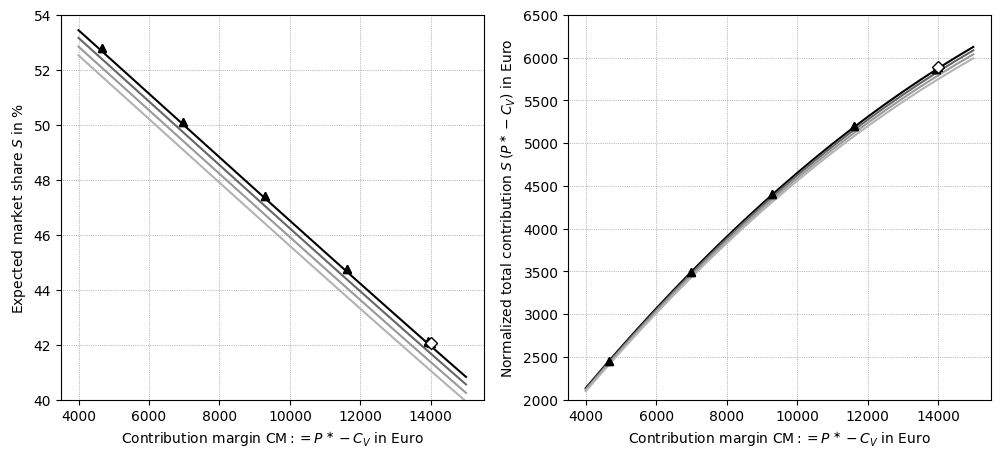

In [137]:
from phdtools.plots.optimization.postprocessing import (
    plot_cost_minimization_price_vs_market_share,
    plot_cost_minimization_price_vs_total_contribution,
)


def plot_price_vs_market_share_vs_total_contribution(
    fname_cost_minimization, fname_summary, powerValuesSI=None, choice_model="mnl"
):

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    plot_cost_minimization_price_vs_market_share(
        fname_cost_minimization, powerValuesSI, choice_model, axs[0]
    )
    plot_cost_minimization_price_vs_total_contribution(
        fname_cost_minimization, powerValuesSI, choice_model, axs[1]
    )

    df = pd.read_csv(fname_summary, comment="#", index_col=[0, 1])

    styles = {
        "Demand maximization with constant markup": {
            "marker": "^",
            "mec": "k",
            "mfc": "w",
            "linestyle": "none",
        },
        "Demand maximization with constant contribution": {
            "marker": "^",
            "mec": "k",
            "mfc": "k",
            "linestyle": "none",
        },
        "Profit maximization": {"marker": "D", "mec": "k", "mfc": "w"},
    }
    models = [
        "Demand maximization with constant markup",
        "Demand maximization with constant contribution",
        "Profit maximization",
    ]
    for mod in models:
        if mod in styles.keys():
            if choice_model == "mnl":
                axs[0].plot(
                    df.loc[mod, "Contribution margin (Euro)"],
                    df.loc[mod, "Market share, MNL (percent)"],
                    **styles[mod],
                    label=f"{mod}",
                )
                axs[1].plot(
                    df.loc[mod, "Contribution margin (Euro)"],
                    df.loc[mod, "Normalized total contribution, MNL (Euro)"],
                    **styles[mod],
                    label=f"{mod}",
                )
            elif choice_model == "mxl":
                axs[0].plot(
                    df.loc[mod, "Contribution margin (Euro)"],
                    df.loc[mod, "Market share, MXL (percent)"],
                    **styles[mod],
                    label=f"{mod}",
                )
                axs[1].plot(
                    df.loc[mod, "Contribution margin (Euro)"],
                    df.loc[mod, "Normalized total contribution, MXL (Euro)"],
                    **styles[mod],
                    label=f"{mod}",
                )
        else:
            print(mod)

    axs[0].set_xlabel(r"Contribution margin $\mathrm{{CM}} := P^\ast - C_V$ in Euro")
    axs[0].set_ylabel(r"Expected market share $S$ in %")

    axs[1].set_xlabel(r"Contribution margin $\mathrm{{CM}} := P^\ast - C_V$ in Euro")
    axs[1].set_ylabel(r"Normalized total contribution $S\,(P^\ast - C_V)$ in Euro")

    for ax in axs.flatten():
        # ax.legend()
        ax.grid()

    for ax in axs.flatten():
        ax.set_xlim(3500, 15500)
        # ax.set_xlim(13500,14500)

    axs[0].set_ylim(40, 54)
    axs[1].set_ylim(2000, 6500)

    # axs[0].set_ylim(41,43)
    # axs[1].set_ylim(5600,6000)

    return fig


_ = plot_price_vs_market_share_vs_total_contribution(
    fname_cost_minimization=(
        DataID(DataType.FIGURE, Chapter.RESULTS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE_COST_MINIMIZATION}_cost_minimization_price_market_share_contribution.csv"
    ),
    fname_summary=(
        DataID(DataType.FIGURE, Chapter.RESULTS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE}_solution_comparison.csv"
    ),
    powerValuesSI=np.array([300, 500, 750, 1000]),
    choice_model="mnl",
)

### Validation of the choice model
[back](#Table-of-contents)

In [138]:
data_id = DataID(DataType.FIGURE, Chapter.RESULTS, 5)

save_price_vs_market_share_vs_total_contribution_data(
    data_id,
    cost_minimization_id=DataID(DataType.FIGURE, Chapter.UNUSED, 25),
    fnames={
        "Cost minimization (markup = markup(profit max.))": DataID(
            DataType.SUPPORT, Chapter.RESULTS, 2
        ).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_constant_markup_margin_of_profit_maximum.csv",
        "Cost minimization (contribution = contribution(profit max.))": DataID(
            DataType.SUPPORT, Chapter.RESULTS, 2
        ).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_constant_contribution_14000.csv",
        "Demand maximization with constant markup": (
            DataID(DataType.TABLE, Chapter.RESULTS, 3).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_markup_solution_summary.csv"
        ),
        "Demand maximization with constant contribution": (
            DataID(DataType.TABLE, Chapter.RESULTS, 4).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_contribution_solution_summary.csv"
        ),
        "Profit maximization": (
            DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE}_profit_maximization_solution_summary.csv"
        ),
    },
    doc=(
        r"Values of expected market share and normalized total contribution based on the original "
        r"MXL model \autocite{Rommel.2017a} compared across the different model variants, with "
        r"variable contribution margins applied to the solutions of the cost-minimization problem."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/se8yjw' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


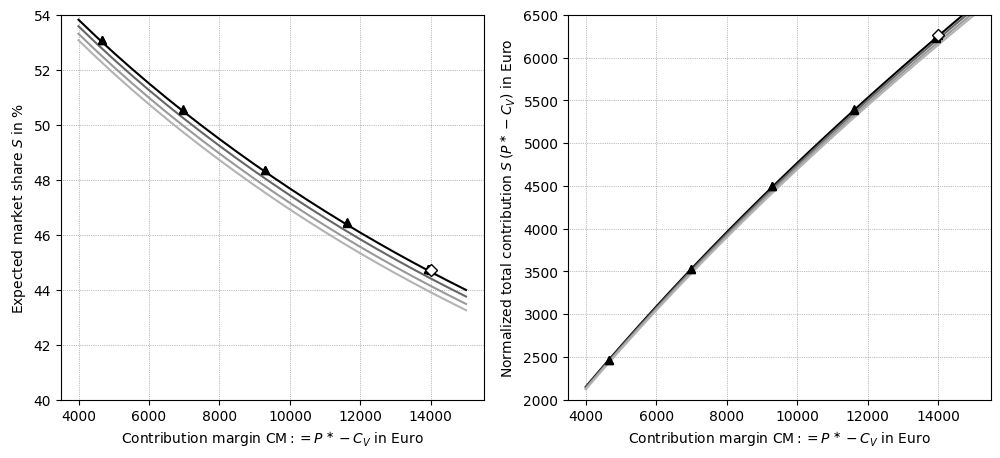

In [139]:
_ = plot_price_vs_market_share_vs_total_contribution(
    fname_cost_minimization=(
        DataID(DataType.FIGURE, Chapter.RESULTS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE_COST_MINIMIZATION}_cost_minimization_price_market_share_contribution.csv"
    ),
    fname_summary=(
        DataID(DataType.FIGURE, Chapter.RESULTS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE}_solution_comparison.csv"
    ),
    powerValuesSI=np.array([300, 500, 750, 1000]),
    choice_model="mxl",
)

In [140]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 26)


@auto_create_path
def save_choice_model_parity_plot(path, fnames):

    summary = create_solution_comparison(fnames)
    description = r"Solution summary across model variants. \n"

    fname = path / f"{TODAY}_solution_comparison.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        summary.to_csv(f)


save_choice_model_parity_plot(
    data_id,
    fnames={
        "Cost minimization (markup = markup(profit max.))": DataID(
            DataType.SUPPORT, Chapter.RESULTS, 2
        ).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_constant_markup_margin_of_profit_maximum.csv",
        "Cost minimization (contribution = contribution(profit max.))": DataID(
            DataType.SUPPORT, Chapter.RESULTS, 2
        ).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_constant_contribution_14000.csv",
        "Demand maximization with constant markup": (
            DataID(DataType.TABLE, Chapter.RESULTS, 3).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_markup_solution_summary.csv"
        ),
        "Demand maximization with constant contribution": (
            DataID(DataType.TABLE, Chapter.RESULTS, 4).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_contribution_solution_summary.csv"
        ),
        "Profit maximization": (
            DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE}_profit_maximization_solution_summary.csv"
        ),
    },
    doc=(
        r"Parity plot of values for market share and normalized total contribution predicted "
        r"by the original MXL model from \textcite{Rommel.2017a} vs. values predicted by its logit approximation "
        r"used in the choice-based optimization model variants."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/iNDafO' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [141]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 26).get_path(fail_exists=False)}

260419_solution_comparison.csv


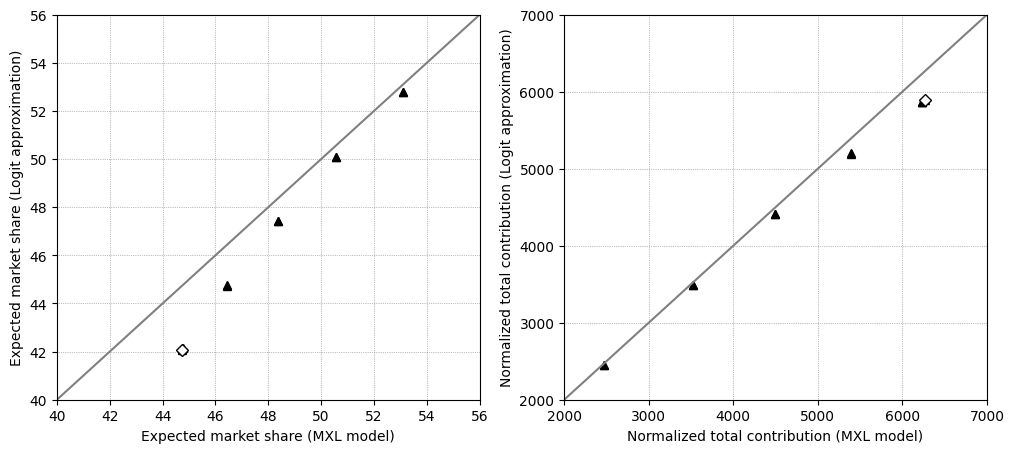

In [142]:
def parity_plot_market_share(fname):

    df = pd.read_csv(fname, comment="#", index_col=[0, 1])

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    styles = {
        "Demand maximization with constant markup": {
            "marker": "^",
            "mec": "k",
            "mfc": "w",
            "linestyle": "none",
        },
        "Demand maximization with constant contribution": {
            "marker": "^",
            "mec": "k",
            "mfc": "k",
            "linestyle": "none",
        },
        "Profit maximization": {"marker": "D", "mec": "k", "mfc": "w"},
    }
    models = [
        "Demand maximization with constant markup",
        "Demand maximization with constant contribution",
        "Profit maximization",
    ]
    for mod in models:
        if mod in styles.keys():
            axs[0].plot(
                df.loc[mod, "Market share, MXL (percent)"],
                df.loc[mod, "Market share, MNL (percent)"],
                **styles[mod],
                label=f"{mod}",
            )
            axs[1].plot(
                df.loc[mod, "Normalized total contribution, MXL (Euro)"],
                df.loc[mod, "Normalized total contribution, MNL (Euro)"],
                **styles[mod],
                label=f"{mod}",
            )

    axs[0].set_xlim(40, 56)
    axs[0].set_ylim(40, 56)

    axs[1].set_xlim(2000, 7000)
    axs[1].set_ylim(2000, 7000)

    for ax in axs:
        ax.grid()
        ax.plot(ax.get_xlim(), ax.get_ylim(), linestyle="-", color="gray")

    axs[0].set_xlabel(r"Expected market share (MXL model)")
    axs[0].set_ylabel(r"Expected market share (Logit approximation)")

    axs[1].set_xlabel(r"Normalized total contribution (MXL model)")
    axs[1].set_ylabel(r"Normalized total contribution (Logit approximation)")

    return fig


_ = parity_plot_market_share(
    DataID(DataType.FIGURE, Chapter.UNUSED, 26).get_path(fail_exists=False)
    / f"{FILE_DATE}_solution_comparison.csv"
)

### Influence of steam-to-carbon ratio on efficiency
[back](#Table-of-contents)

In [143]:
from phdtools.optimization.postprocessing import (
    energyCostSavingsModel,
    carbonDioxideEmissionReductionsModel,
)
from phdtools.optimization import MATCHING_FACTOR

In [144]:
data_id = DataID(DataType.FIGURE, Chapter.RESULTS, 6)


@auto_create_path
def save_variable_costs_vs_efficiency_data(path, fnames):

    df = create_solution_comparison(fnames)  # .dropna(axis=1)

    thermalEfficiency = df.loc[:, "Thermal efficiency"].to_numpy()
    powerIndex = (
        df.loc[:, "Electrical power (kW)"].to_numpy()
        / df.loc[:, "Thermal power (kW)"].to_numpy()
    )
    matchingFactor = MATCHING_FACTOR * np.ones(len(thermalEfficiency))

    energyCostSavings = np.full(len(thermalEfficiency), np.nan)
    for num in range(len(energyCostSavings)):
        energyCostSavings[num] = energyCostSavingsModel(
            thermalEfficiency=thermalEfficiency[num],
            powerIndex=powerIndex[num],
            matchingFactor=matchingFactor[num],
            fname_heat=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                / f"{FILE_DATE_DEMANDS}_annual_heating_demands_{16}.csv"
            ),
            fname_electricity=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                / f"{FILE_DATE_DEMANDS}_annual_electricity_demands_{16}.csv"
            ),
        ).mean()

    carbonDioxideEmissionReductions = np.full(len(thermalEfficiency), np.nan)
    for num in range(len(carbonDioxideEmissionReductions)):
        carbonDioxideEmissionReductions[num] = carbonDioxideEmissionReductionsModel(
            thermalEfficiency=thermalEfficiency[num],
            powerIndex=powerIndex[num],
            fname_heat=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                / f"{FILE_DATE_DEMANDS}_annual_heating_demands_{16}.csv"
            ),
            fname_electricity=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                / f"{FILE_DATE_DEMANDS}_annual_electricity_demands_{16}.csv"
            ),
        ).mean()

    mask = np.isclose(df.loc[:, "Electrical power (kW)"], 1.0, rtol=1e-2)
    df.loc[:, "Sample mean energy cost savings"] = energyCostSavings
    df.loc[:, "Sample mean CO2 savings"] = carbonDioxideEmissionReductions

    fname = path / f"{TODAY}_variable_costs_vs_efficiency.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        df[mask].loc[
            :,
            [
                "Thermal efficiency",
                "Variable costs (Euro)",
                "Sample mean energy cost savings",
                "Sample mean CO2 savings",
                "Contribution margin (Euro)",
                "Markup",
            ],
        ].to_csv(f)


save_variable_costs_vs_efficiency_data(
    data_id,
    fnames={
        "Cost minimization": (
            DataID(DataType.TABLE, Chapter.RESULTS, 1).get_path(fail_exists=False)
            / f"{FILE_DATE_COST_MINIMIZATION}_cost_minimization_solution_summary.csv"
        ),
        "Demand maximization with constant markup": (
            DataID(DataType.TABLE, Chapter.RESULTS, 3).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_markup_solution_summary.csv"
        ),
        "Demand maximization with constant contribution": (
            DataID(DataType.TABLE, Chapter.RESULTS, 4).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_contribution_solution_summary.csv"
        ),
        "Profit maximization": (
            DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE}_profit_maximization_solution_summary.csv"
        ),
    },
    doc=(
        "Optimal values of thermal efficiency, variable costs, sample mean energy costs savings, "
        "and sample mean carbon-dioxide emissions reductions compared across the different optimization model variants."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/uE2lY5' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [145]:
!ls {DataID(DataType.FIGURE, Chapter.RESULTS, 6).get_path(fail_exists=False)}

260419_variable_costs_vs_efficiency.csv


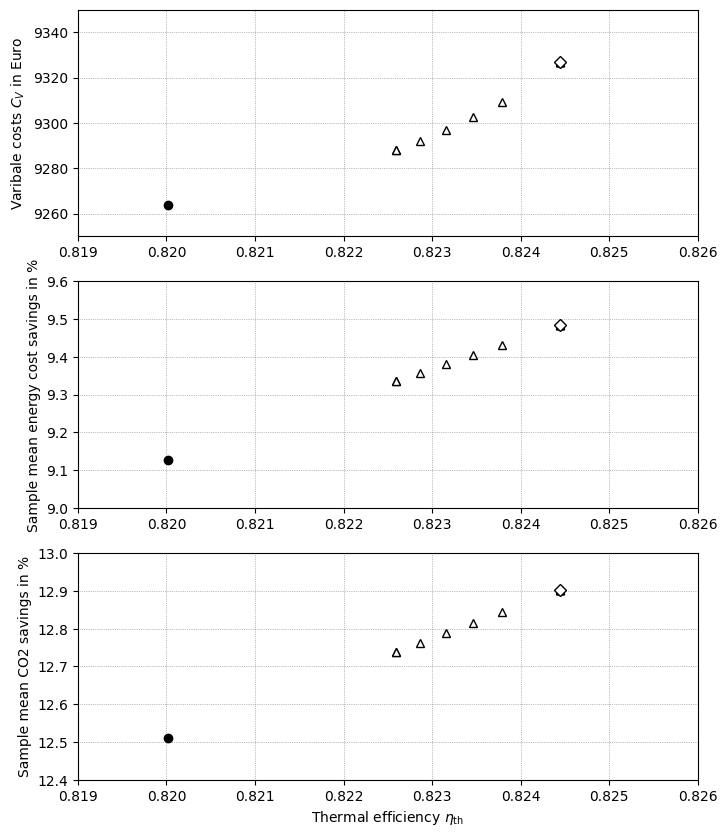

In [146]:
def plot_variable_costs_vs_efficiency(fname):

    df = pd.read_csv(fname, comment="#", index_col=[0, 1])

    fig, axs = plt.subplots(3, 1, figsize=(8, 10))

    styles = {
        "Cost minimization": {
            "marker": "o",
            "mec": "k",
            "mfc": "k",
            "linestyle": "none",
        },
        "Demand maximization with constant markup": {
            "marker": "^",
            "mec": "k",
            "mfc": "w",
            "linestyle": "none",
        },
        "Demand maximization with constant contribution": {
            "marker": "^",
            "mec": "k",
            "mfc": "k",
            "linestyle": "none",
        },
        "Profit maximization": {
            "marker": "D",
            "mec": "k",
            "mfc": "w",
            "linestyle": "none",
        },
    }

    models = [
        "Cost minimization",
        "Demand maximization with constant markup",
        "Demand maximization with constant contribution",
        "Profit maximization",
    ]
    for mod in models:
        axs[0].plot(
            df.loc[mod, "Thermal efficiency"],
            df.loc[mod, "Variable costs (Euro)"],
            **styles[mod],
            label=f"{mod}",
        )
        axs[1].plot(
            df.loc[mod, "Thermal efficiency"],
            100 * df.loc[mod, "Sample mean energy cost savings"],
            **styles[mod],
            label=f"{mod}",
        )
        axs[2].plot(
            df.loc[mod, "Thermal efficiency"],
            100 * df.loc[mod, "Sample mean CO2 savings"],
            **styles[mod],
            label=f"{mod}",
        )

    axs[2].set_xlabel(rf"Thermal efficiency $\eta_\mathrm{{th}}$")

    axs[0].set_ylabel(rf"Varibale costs $C_V$ in Euro")
    axs[1].set_ylabel(rf"Sample mean energy cost savings in %")
    axs[2].set_ylabel(rf"Sample mean CO2 savings in %")

    for ax in axs:
        ax.set_xlim(0.819, 0.826)

    axs[0].set_ylim(9250, 9350)
    axs[1].set_ylim(9.0, 9.6)
    axs[2].set_ylim(12.4, 13.0)

    # ax.legend()
    for ax in axs:
        ax.grid()


plot_variable_costs_vs_efficiency(
    fname=(
        DataID(DataType.FIGURE, Chapter.RESULTS, 6).get_path(fail_exists=False)
        / f"{FILE_DATE}_variable_costs_vs_efficiency.csv"
    ),
)

In [147]:
data_id = DataID(DataType.FIGURE, Chapter.RESULTS, 7)


@auto_create_path
def save_steam_to_carbon_ratio_vs_efficiency_and_reactor_size(path, fnames):

    df = create_solution_comparison(fnames)  # .dropna(axis=1)
    mask = np.isclose(df.loc[:, "Electrical power (kW)"], 1.0, rtol=1e-2)

    fname = path / f"{TODAY}_steam_to_carbon_ratio_vs_efficiency_and_reactor_size.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        df[mask].loc[
            :,
            [
                "Steam-to-carbon ratio (H2O/CH4)",
                "Thermal efficiency",
                "Catalyst mass reformer (g)",
                "Catalyst mass shift reactor (g)",
                "Contribution margin (Euro)",
                "Markup",
            ],
        ].to_csv(f)


save_steam_to_carbon_ratio_vs_efficiency_and_reactor_size(
    data_id,
    fnames={
        "Cost minimization": (
            DataID(DataType.TABLE, Chapter.RESULTS, 1).get_path(fail_exists=False)
            / f"{FILE_DATE_COST_MINIMIZATION}_cost_minimization_solution_summary.csv"
        ),
        "Demand maximization with constant markup": (
            DataID(DataType.TABLE, Chapter.RESULTS, 3).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_markup_solution_summary.csv"
        ),
        "Demand maximization with constant contribution": (
            DataID(DataType.TABLE, Chapter.RESULTS, 4).get_path(fail_exists=False)
            / f"{FILE_DATE}_demand_maximization_contribution_solution_summary.csv"
        ),
        "Profit maximization": (
            DataID(DataType.SUPPORT, Chapter.RESULTS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE}_profit_maximization_solution_summary.csv"
        ),
    },
    doc=(
        "Optimal values of steam-to-carbon ratio, thermal efficiency, and catalyst mass "
        "compared across the different optimization model variants."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/7OdxDB' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [148]:
!ls {DataID(DataType.FIGURE, Chapter.RESULTS, 7).get_path(fail_exists=False)}

260419_steam_to_carbon_ratio_vs_efficiency_and_reactor_size.csv


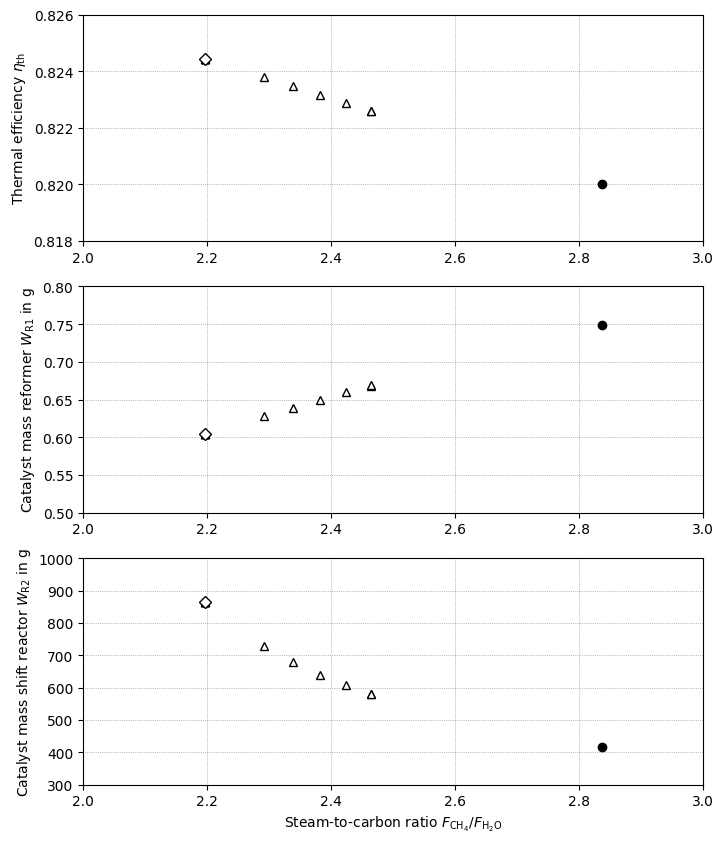

In [149]:
def plot_steam_to_carbon_ratio_vs_catalyst_mass(fname):

    df = pd.read_csv(fname, comment="#", index_col=[0, 1])

    fig, axs = plt.subplots(3, 1, figsize=(8, 10))

    styles = {
        "Cost minimization": {
            "marker": "o",
            "mec": "k",
            "mfc": "k",
            "linestyle": "none",
        },
        "Demand maximization with constant markup": {
            "marker": "^",
            "mec": "k",
            "mfc": "w",
            "linestyle": "none",
        },
        "Demand maximization with constant contribution": {
            "marker": "^",
            "mec": "k",
            "mfc": "k",
            "linestyle": "none",
        },
        "Profit maximization": {
            "marker": "D",
            "mec": "k",
            "mfc": "w",
            "linestyle": "none",
        },
    }
    models = [
        "Cost minimization",
        "Demand maximization with constant markup",
        "Demand maximization with constant contribution",
        "Profit maximization",
    ]
    for mod in models:

        axs[0].plot(
            df.loc[mod, "Steam-to-carbon ratio (H2O/CH4)"],
            df.loc[mod, "Thermal efficiency"],
            **styles[mod],
        )

        axs[1].plot(
            df.loc[mod, "Steam-to-carbon ratio (H2O/CH4)"],
            df.loc[mod, "Catalyst mass reformer (g)"],
            **styles[mod],
            label=f"{mod}",
        )
        axs[2].plot(
            df.loc[mod, "Steam-to-carbon ratio (H2O/CH4)"],
            df.loc[mod, "Catalyst mass shift reactor (g)"],
            **styles[mod],
            label=f"{mod}",
        )

        # axs[1].plot(df.loc[mod,"Steam-to-carbon ratio (H2O/CH4)"], df.loc[mod,"Space-time reformer (g(cat)*h/mol)"], **styles[mod], label=f"{mod}")
        # axs[2].plot(df.loc[mod,"Steam-to-carbon ratio (H2O/CH4)"], df.loc[mod,"Space-time shift (g(cat)*h/mol)"], **styles[mod], label=f"{mod}")

    axs[2].set_xlabel(rf"Steam-to-carbon ratio $F_\mathrm{{CH_4}}/F_\mathrm{{H_2O}}$")

    axs[0].set_ylabel(rf"Thermal efficiency $\eta_\mathrm{{th}}$")
    axs[1].set_ylabel(rf"Catalyst mass reformer $W_\mathrm{{R1}}$ in g")
    axs[2].set_ylabel(rf"Catalyst mass shift reactor $W_\mathrm{{R2}}$ in g")
    # axs[1].set_ylabel(rf"Space-time reformer $W_\mathrm{{R1}}/F_\mathrm{{CH_4,0}}$")
    # axs[2].set_ylabel(rf"Space-time shift reactor $W_\mathrm{{R2}}/F_\mathrm{{CO,O}}$")

    axs[0].set_ylim(0.818, 0.826)
    axs[1].set_ylim(0.5, 0.8)
    axs[2].set_ylim(300, 1000)

    # ax.legend()
    for ax in axs:
        ax.set_xlim(2, 3)
        ax.grid()


plot_steam_to_carbon_ratio_vs_catalyst_mass(
    fname=(
        DataID(DataType.FIGURE, Chapter.RESULTS, 7).get_path(fail_exists=False)
        / f"{FILE_DATE}_steam_to_carbon_ratio_vs_efficiency_and_reactor_size.csv"
    ),
)

## Comparison of computational performance
[back](#Table-of-contents)

In [150]:
data_id = DataID(DataType.TABLE, Chapter.RESULTS, 8)


@auto_create_path
def save_solver_stats_summary(
    path,
    fname_cost_minimization_summary,
    fname_demand_maximization_markup_summary,
    fname_demand_maximization_contribution_summary,
    fname_profit_maximization,
):

    cost_minimization = (
        pd.read_csv(
            fname_cost_minimization_summary,
            index_col=0,
            comment="#",
        )
        .loc[["Time (sec)", "Nodes", "Gap (percent)"]]
        .T
    )

    demand_maximization_markup = (
        pd.read_csv(
            fname_demand_maximization_markup_summary,
            index_col=0,
            comment="#",
        )
        .loc[["Time (sec)", "Nodes", "Gap (percent)"]]
        .T
    )

    demand_maximization_contribution = (
        pd.read_csv(
            fname_demand_maximization_contribution_summary,
            index_col=0,
            comment="#",
        )
        .loc[["Time (sec)", "Nodes", "Gap (percent)"]]
        .T
    )

    results = SolverResults()
    results.read(filename=fname_profit_maximization)

    if (results.solver.status == SolverStatus.ok) and (
        results.solver.termination_condition != pyo.TerminationCondition.infeasible
    ):
        profit_maximization = pd.Series(
            {
                "Time (sec)": results.solver.time,
                "Nodes": int(results.solver.node_count),
                "Gap (percent)": results.solver.Gap,
            },
        )

    stats = lambda df: df.agg(["mean", "min", "max"])

    df = pd.concat(
        {
            "Cost minimization": stats(cost_minimization),
            "Demand maximization (constant markup)": stats(demand_maximization_markup),
            "Demand maximization (constant contribution)": stats(
                demand_maximization_contribution
            ),
            "Profit maximization": profit_maximization.to_frame().T.rename(
                index={0: "value"}
            ),
        },
        names=["Model", "Statistic"],
    )

    instances = {
        "Cost minimization": cost_minimization.shape[0],
        "Demand maximization (constant markup)": demand_maximization_markup.shape[0],
        "Demand maximization (constant contribution)": demand_maximization_contribution.shape[
            0
        ],
        "Profit maximization": 1,
    }

    df["No. instances"] = df.index.get_level_values("Model").map(instances)

    description = r"Solver statistics summary (using \SCIP{}) across all instances. \n"

    fname = path / f"{TODAY}_solver_statistics_summary.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        df.to_csv(f)


save_solver_stats_summary(
    data_id=data_id,
    fname_cost_minimization_summary=(
        DataID(DataType.TABLE, Chapter.RESULTS, 2).get_path(fail_exists=False)
        / f"{FILE_DATE_COST_MINIMIZATION}_cost_minimization_solver_statistics.csv"
    ),
    fname_demand_maximization_markup_summary=(
        DataID(DataType.TABLE, Chapter.RESULTS, 6).get_path(fail_exists=False)
        / f"{FILE_DATE}_demand_maximization_markup_solver_statistics.csv"
    ),
    fname_demand_maximization_contribution_summary=(
        DataID(DataType.TABLE, Chapter.RESULTS, 7).get_path(fail_exists=False)
        / f"{FILE_DATE}_demand_maximization_contribution_solver_statistics.csv"
    ),
    fname_profit_maximization=(
        DataID(DataType.SUPPORT, Chapter.RESULTS, 5).get_path(fail_exists=False)
        / f"results_1.yaml"
    ),
    doc=(r"Solver statistics across all instances (using \SCIP{}). "),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/rvCFlj' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [151]:
!ls {DataID(DataType.TABLE, Chapter.RESULTS, 8).get_path(fail_exists=False)}

260419_solver_statistics_summary.csv


In [152]:
pd.read_csv(
    DataID(DataType.TABLE, Chapter.RESULTS, 8).get_path(fail_exists=False)
    / f"{FILE_DATE}_solver_statistics_summary.csv",
    comment="#",
    index_col=0,
)

,Statistic,Time (sec),Nodes,Gap (percent),No. instances
Model,,,,,
Cost minimization,mean,30.0,47.800000,0.914667,15
Cost minimization,min,30.0,17.000000,0.910000,15
Cost minimization,max,30.0,90.000000,0.920000,15
Demand maximization (constant markup),mean,30.0,370.166667,6.895000,6
Demand maximization (constant markup),min,30.0,204.000000,5.420000,6
Demand maximization (constant markup),max,30.0,605.000000,7.990000,6
Demand maximization (constant contribution),mean,30.0,232.500000,4.911667,6
Demand maximization (constant contribution),min,30.0,48.000000,1.720000,6
Demand maximization (constant contribution),max,30.0,445.000000,6.180000,6


### Problem statistics
[back](#Table-of-contents)

In [153]:
# !ls {DataID(DataType.TABLE, Chapter.METHODS, 5).get_path(fail_exists=False)}

In [154]:
# request_free_id(DataType.TABLE, Chapter.METHODS)

In [155]:
import yaml

from phdtools.optimization.pyomo.cost_minimization import (
    create_abstract_model as create_abstract_cost_minimization_model,
)
from phdtools.optimization.pyomo.demand_maximization_markup import (
    create_abstract_model as create_abstract_demand_maximization_markup_model,
)
from phdtools.optimization.pyomo.demand_maximization_contribution import (
    create_abstract_model as create_abstract_demand_maximization_contribution_model,
)
from phdtools.optimization.pyomo.profit_maximization import (
    create_abstract_model as create_abstract_profit_maximization_model,
)

data_id = DataID(DataType.TABLE, Chapter.METHODS, 5)


@auto_create_path
def write_problem_statistics(path):
    stats = {}

    models = [
        create_abstract_cost_minimization_model(),
        create_abstract_demand_maximization_markup_model(),
        create_abstract_demand_maximization_contribution_model(),
        create_abstract_profit_maximization_model(),
    ]

    outdirs = [
        DataID(DataType.SUPPORT, Chapter.RESULTS, 1).get_path(fail_exists=False),
        DataID(DataType.SUPPORT, Chapter.RESULTS, 3).get_path(fail_exists=False),
        DataID(DataType.SUPPORT, Chapter.RESULTS, 4).get_path(fail_exists=False),
        DataID(DataType.SUPPORT, Chapter.RESULTS, 5).get_path(fail_exists=False),
    ]

    fnames = [
        f"cost_minimization_1.dat",
        f"demand_maximization_markup_1.dat",
        f"demand_maximization_contribution_1.dat",
        f"profit_maximization_1.dat",
    ]

    for model, outdir, fname in zip(models, outdirs, fnames):
        with chdir(outdir):
            dp = pyo.DataPortal(filename=fname)

            model.reformer.construct(dp.data(namespace="reformer"))
            model.shift.construct(dp.data(namespace="shift"))
            model.fuel_cell.construct(dp.data(namespace="fuel_cell"))
            instance = model.create_instance(dp, namespace=None)

        stats[model.name] = create_pyomo_problem_statistics(instance)

        fname = path / f"{TODAY}_problem_statistics.yaml"
        with open(fname, "w") as f:
            yaml.dump(stats, f)


write_problem_statistics(
    data_id=data_id,
    doc="Number of variables and constraints of the different model variants.",
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/9LFaqF' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [156]:
!ls {DataID(DataType.TABLE, Chapter.METHODS, 5).get_path(fail_exists=False)}

260419_problem_statistics.yaml


In [157]:
fname = (
    DataID(DataType.TABLE, Chapter.METHODS, 5).get_path(fail_exists=False)
    / f"{FILE_DATE}_problem_statistics.yaml"
)
!cat { fname }

Cost minimization:
  constraints:
    linear: 128
    non-polynomial nonlinear: 48
    polynomial: 0
    quadratic: 133
    total: 309
  variables:
    binary: 0
    continuous: 302
    integer: 0
    total: 302
Demand maximization with constant contribution:
  constraints:
    linear: 157
    non-polynomial nonlinear: 49
    polynomial: 0
    quadratic: 133
    total: 339
  variables:
    binary: 0
    continuous: 326
    integer: 0
    total: 326
Demand maximization with constant markup:
  constraints:
    linear: 157
    non-polynomial nonlinear: 49
    polynomial: 0
    quadratic: 133
    total: 339
  variables:
    binary: 0
    continuous: 326
    integer: 0
    total: 326
Profit maximization:
  constraints:
    linear: 157
    non-polynomial nonlinear: 49
    polynomial: 0
    quadratic: 134
    total: 340
  variables:
    binary: 0
    continuous: 328
    integer: 0
    total: 328
